# 🧬 ACMG Variant Classifier: Pathogenicity Prediction

## 1. Project Overview
This project aims to automate the classification of genetic variants (Benign vs. Pathogenic) based on ClinVar data and **ACMG (American College of Medical Genetics)** guidelines. The solution leverages machine learning (XGBoost) to identify pathogenic variants with high precision, aiding clinical decision-making.

## 2. Key Results
* **Performance:** Achieved **ROC AUC of 0.993** on the test set.
* **Data Strategy:** Focused on binary classification (excluding VUS) using rigorous feature engineering (ACMG rules implementation).
* **Explainability:** Integrated SHAP analysis to ensure the model relies on biologically relevant features rather than noise.

## 3. Tech Stack
* **Core:** Python, Scikit-Learn, Pandas
* **Model:** XGBoost (optimized via Optuna)
* **Ops:** MLflow (tracking), Docker (deployment), FastAPI (inference)

In [1]:
from sklearn.model_selection import train_test_split, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import requests, gzip, shutil
import argparse
import os
import subprocess
import warnings
import pandas as pd
import numpy as np
import myvariant
import time
import re
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn import set_config
set_config(transform_output="pandas")
from sklearn.metrics import classification_report, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import mlflow
import shap
import optuna
from optuna.integration.mlflow import MLflowCallback
import mygene


c:\Users\szymo\Desktop\Projekty\karpie\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

url = "https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz"
vcf_gz = "clinvar.vcf.gz"
vcf_file = "clinvar.vcf"

print("[+] Downloading ClinVar VCF...")
with requests.get(url, stream=True) as r:
    r.raise_for_status()
    with open(vcf_gz, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
print("[✓] File Downloaded:", vcf_gz)

print("[+] Unboxing file...")
with gzip.open(vcf_gz, "rb") as f_in:
    with open(vcf_file, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)
print("[✓] Unboxed too:", vcf_file)

[+] Downloading ClinVar VCF...
[✓] File Downloaded: clinvar.vcf.gz
[+] Unboxing file...
[✓] Unboxed too: clinvar.vcf


In [3]:


def parse_vcf(vcf_path, limit=None):
    """
    Parser tekstowy pliku VCF (np. ClinVar) do pandas DataFrame.
    Rozbija INFO na osobne kolumny, uzupełnia brakujące BASE_COLUMNS.
    """
    def parse_info(info_str):
        parsed = {}
        for item in info_str.split(';'):
            if '=' in item:
                key, value = item.split('=')
                parsed[key] = value
            else:
                parsed[item] = True
        return parsed

    records = []
    headers = []

    with open(vcf_path, 'r', encoding='UTF-8', errors='replacce') as file:
        for line in file:
            if line.startswith('##'):
                continue
            elif line.startswith('#CHROM'):
                headers = line.strip().lstrip('#').split('\t')
                continue

            row = line.strip().split('\t')
            record = dict(zip(headers, row))

            if 'INFO' in record:
                record.update(parse_info(record['INFO']))

            records.append(record)
            if limit and len(records) >= limit:
                break

    return pd.DataFrame(records)

def standarize_df(df):
    keep_list = [
    'CHROM', 'POS', 'REF', 'ALT', 
        
        'MC',         
        'GENEINFO',   
        'CLNVC',      
        'AF_EXAC', 'AF_TGP', 'AF_ESP',
        'ORIGIN',     
        'CLNREVSTAT', 
        'CLNDN']
    labels = df['CLNSIG'] if 'CLNSIG' in df.columns else pd.Series([None] * len(df))
    features_df =  df.drop(columns=['CLNSIG'], errors ='ignore')
    existing_keep_cols = [col for col in keep_list if col in features_df.columns]
    missing_cols = [col for col in keep_list if col not in features_df.columns]
    if missing_cols:
      print(f'[WARNING] Can not find: {missing_cols}')
    df_filtered = features_df[existing_keep_cols]

    return df_filtered, labels


def process_input(input_type, **kwargs):
    if input_type == 'vcf':
        vcf_path = kwargs.get('vcf_path')
        limit = kwargs.get('limit', None)
        print(f'[INFO] Reading file: {vcf_path} (limit={limit})')
        df = parse_vcf(vcf_path, limit)
        return standarize_df(df)
    else:
        raise ValueError('Not known input type!')

In [4]:
df_feautures, df_labels = process_input(
    input_type="vcf",
    vcf_path = 'clinvar.vcf',
    limit=None
)
df_full = df_feautures.copy()
df_full['CLNSIG'] = df_labels.copy()

[INFO] Reading file: clinvar.vcf (limit=None)


In [5]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4136808 entries, 0 to 4136807
Data columns (total 14 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   CHROM       object
 1   POS         object
 2   REF         object
 3   ALT         object
 4   MC          object
 5   GENEINFO    object
 6   CLNVC       object
 7   AF_EXAC     object
 8   AF_TGP      object
 9   AF_ESP      object
 10  ORIGIN      object
 11  CLNREVSTAT  object
 12  CLNDN       object
 13  CLNSIG      object
dtypes: object(14)
memory usage: 441.9+ MB


In [6]:
mapping_acmg = {
    #BENIGN
    "Benign": 0,
    "Benign/Likely_benign": 0,
    "Benign|risk_factor": 0,
    "Benign|other": 0,
    "Benign|association": 0,
    "Benign/Likely_benign|other": 0,
    "Benign|Affects": 0,
    "Benign|drug_response": 0,
    "Benign|protective": 0,

    #LIKELY BENIGN
    "Likely_benign": 0,
    "Likely_benign|other": 0,
    "Likely_benign|drug_response": 0,
    "Likely_benign|drug_response|other": 0,

    #UNCERTAIN SIGNIFICANCE (VUS)
    "Uncertain_significance": -1,
    "Conflicting_classifications_of_pathogenicity": -1,
    "not_provided": -1,
    "no_classification_for_the_single_variant": -1,
    "no_classifications_from_unflagged_records": -1,
    "other": -1,
    "association": -1,
    "association_not_found": -1,
    "Uncertain_significance/Uncertain_risk_allele": -1,
    "Uncertain_risk_allele": -1,
    "Uncertain_significance|other": -1,
    "Uncertain_significance|risk_factor": -1,
    "Uncertain_significance|drug_response": -1,
    "Uncertain_significance|association": -1,
    "Conflicting_classifications_of_pathogenicity|other": -1,
    "Conflicting_classifications_of_pathogenicity|risk_factor": -1,
    "Conflicting_classifications_of_pathogenicity|drug_response": -1,
    "Conflicting_classifications_of_pathogenicity|association": -1,

    # 4️ LIKELY PATHOGENIC
    "Likely_pathogenic": 1,
    "Likely_pathogenic|drug_response": 1,
    "Likely_pathogenic|risk_factor": 1,
    "Likely_pathogenic/Likely_risk_allele": 1,
    "Likely_pathogenic|association": 1,
    "Likely_pathogenic,_low_penetrance": 1,

    # PATHOGENIC
    "Pathogenic": 1,
    "Pathogenic/Likely_pathogenic": 1,
    "Pathogenic|other": 1,
    "Pathogenic|drug_response": 1,
    "Pathogenic|risk_factor": 1,
    "Pathogenic/Likely_risk_allele": 1,
    "Pathogenic|Affects": 1,
    "Pathogenic/Likely_pathogenic|risk_factor": 1,
    "Pathogenic/Likely_pathogenic|other": 1,
    "Pathogenic/Likely_pathogenic/Pathogenic,_low_penetrance": 1,
    "Pathogenic/Likely_pathogenic/Likely_risk_allele": 1
}

In [7]:
df_full['CLNSIG'] = df_full['CLNSIG'].map(mapping_acmg)

In [8]:
df_full['CLNSIG'].isna().mean()

np.float64(0.059672820203403205)

In [9]:
df_full = df_full.dropna(subset=['CLNSIG'])

In [10]:
df_full['CLNSIG'].isna().mean()

np.float64(0.0)

In [11]:
df_full['CLNSIG'].value_counts()

CLNSIG
-1.0    2289587
 0.0    1279971
 1.0     320395
Name: count, dtype: int64

In [12]:
df_vus = df_full[df_full['CLNSIG'] == -1.0].copy()
df = df_full[df_full['CLNSIG'] != -1.0].copy()

In [13]:
df_vus.head() 

,CHROM,POS,REF,ALT,MC,GENEINFO,CLNVC,AF_EXAC,AF_TGP,AF_ESP,ORIGIN,CLNREVSTAT,CLNDN,CLNSIG
0,1,66926,AG,A,SO:0001627|intron_variant,OR4F5:79501,Deletion,NaN,NaN,NaN,0,"criteria_provided,_single_submitter",Retinitis_pigmentosa,-1.0
2,1,69308,A,G,SO:0001583|missense_variant,OR4F5:79501,single_nucleotide_variant,NaN,NaN,NaN,1,"criteria_provided,_single_submitter",not_specified,-1.0
3,1,69314,T,G,SO:0001583|missense_variant,OR4F5:79501,single_nucleotide_variant,NaN,NaN,NaN,1,"criteria_provided,_single_submitter",not_specified,-1.0
4,1,69404,T,C,SO:0001583|missense_variant,OR4F5:79501,single_nucleotide_variant,NaN,NaN,NaN,1,"criteria_provided,_single_submitter",not_specified,-1.0
5,1,69423,G,A,SO:0001583|missense_variant,OR4F5:79501,single_nucleotide_variant,NaN,NaN,NaN,1,"criteria_provided,_single_submitter",not_specified,-1.0


In [14]:
df['CLNSIG'].value_counts()

CLNSIG
0.0    1279971
1.0     320395
Name: count, dtype: int64

In [15]:
samples_per_class = 10_000

df_balanced = df.groupby('CLNSIG').apply(
        lambda x: x.sample(min(len(x), samples_per_class), random_state=42), 
        include_groups=False).reset_index(level=0)               


In [16]:
df_balanced.head()

,CLNSIG,CHROM,POS,REF,ALT,MC,GENEINFO,CLNVC,AF_EXAC,AF_TGP,AF_ESP,ORIGIN,CLNREVSTAT,CLNDN
2830295,0.0,15,34232783,C,T,SO:0001624|3_prime_UTR_variant,SLC12A6:9990,single_nucleotide_variant,NaN,0.01558,NaN,1,"criteria_provided,_single_submitter",Agenesis_of_the_corpus_callosum_with_periphera...
1851542,0.0,9,13158080,C,T,"SO:0001627|intron_variant,SO:0001819|synonymou...",MPDZ:8777,single_nucleotide_variant,0.00009,NaN,0.00008,1,"criteria_provided,_single_submitter",not_provided|MPDZ-related_disorder
751000,0.0,3,10342870,G,T,SO:0001819|synonymous_variant,ATP2B2:491,single_nucleotide_variant,NaN,NaN,NaN,1,"criteria_provided,_single_submitter",not_provided
571283,0.0,2,165344752,C,T,SO:0001819|synonymous_variant,SCN2A:6326,single_nucleotide_variant,NaN,NaN,NaN,1,"criteria_provided,_single_submitter",not_specified
2340320,0.0,11,94464402,C,T,SO:0001627|intron_variant,MRE11:4361,single_nucleotide_variant,NaN,0.31490,NaN,1,"criteria_provided,_multiple_submitters,_no_con...",not_provided


In [17]:
df_balanced['CLNSIG'].value_counts()

CLNSIG
0.0    10000
1.0    10000
Name: count, dtype: int64

In [18]:
df_balanced['CHROM'].value_counts()

CHROM
2     2048
1     1590
17    1372
11    1218
X     1124
3     1051
16    1045
5      971
7      925
6      906
19     881
9      818
12     814
15     743
10     698
8      658
4      652
14     575
13     541
22     439
20     356
18     328
21     223
MT      22
Y        2
Name: count, dtype: int64

In [19]:


def annotate_with_myvariant(df):
    mv = myvariant.MyVariantInfo()
    
    print("[+] Generating HGVS ID for GRCh38...")
    
    
    def make_hgvs(row):
        chrom = str(row['CHROM']).strip()
        if chrom == 'MT': chrom = 'M'
        if not chrom.startswith('chr'): chrom = f"chr{chrom}"
        return f"{chrom}:g.{str(row['POS']).strip()}{str(row['REF']).strip()}>{str(row['ALT']).strip()}"

    hg38_ids = df.apply(make_hgvs, axis=1).tolist()
    fields = [
        'gnomad_exome.af.af',
        'cadd.phred',                     
        'dbnsfp.phylop.100way_vertebrate.score', 
        'dbnsfp.revel.score',             
        'dbnsfp.interpro.domain',
        'gnomad_exome.constraints.pli',
        'dbnsfp.spliceai_ds_max',         
        'dbnsfp.dbscsnv.ada_score',       
        'dbnsfp.dbscsnv.rf_score'
    ]
    
    batch_size = 1000
    all_results = []
    total = len(hg38_ids)
    
    
    for i in range(0, total, batch_size):
        batch = hg38_ids[i:i+batch_size]
        try:
            res = mv.getvariants(batch, fields=",".join(fields), assembly='hg38', as_dataframe=True)
            
            if not res.empty:
                if 'notfound' in res.columns:
                    res = res[res['notfound'].isna()]
                res.index.name = 'query_id'
                res = res.reset_index()
                all_results.append(res)
                
                print(f"   -> Partia {i}-{min(i+batch_size, total)} OK")
            
        except Exception as e:
            print(f"   [!] Error in  {i}: {e}")
        
        time.sleep(0.2)

    if not all_results:
        df_final = df.copy()
        for col in fields:
            df_final[col] = np.nan
        return df_final

    df_anno = pd.concat(all_results)
    df_anno = df_anno.drop_duplicates(subset=['query_id'])
    
    for col in fields:
        if col not in df_anno.columns:
            df_anno[col] = np.nan


    def clean_value(x):
        if isinstance(x, list):
            valid_x = [v for v in x if pd.notna(v)]
            if not valid_x: return np.nan
            try:
                return max(valid_x) 
            except:
                return valid_x[0]
        return x

    cols_to_clean = [
        'cadd.phred', 
        'dbnsfp.revel.score', 
        'dbnsfp.spliceai_ds_max', 
        'gnomad_exome.constraints.pli', 
        'dbnsfp.phylop.100way_vertebrate.score',
        'gnomad_exome.af.af'
    ]
    
    for col in cols_to_clean:
        if col in df_anno.columns:
            df_anno[col] = df_anno[col].apply(clean_value)
            df_anno[col] = pd.to_numeric(df_anno[col], errors='coerce')

    df['hg38_temp'] = hg38_ids
    df_final = df.merge(df_anno, left_on='hg38_temp', right_on='query_id', how='left')
    
    cols_drop = ['hg38_temp', 'query_id', '_id', '_version', 'query', 'notfound']
    df_final.drop(columns=[c for c in cols_drop if c in df_final.columns], inplace=True, errors='ignore')
    
    return df_final

In [20]:
df_full_annotate = annotate_with_myvariant(df_balanced)


[+] Generating HGVS ID for GRCh38...


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


   -> Partia 0-1000 OK
   -> Partia 1000-2000 OK


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


   -> Partia 2000-3000 OK
   -> Partia 3000-4000 OK


Input sequence provided is already in string format. No operation performed


   -> Partia 4000-5000 OK


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


   -> Partia 5000-6000 OK


Input sequence provided is already in string format. No operation performed


   -> Partia 6000-7000 OK
   -> Partia 7000-8000 OK


Input sequence provided is already in string format. No operation performed


   -> Partia 8000-9000 OK


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


   -> Partia 9000-10000 OK
   -> Partia 10000-11000 OK


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


   -> Partia 11000-12000 OK
   -> Partia 12000-13000 OK


Input sequence provided is already in string format. No operation performed


   -> Partia 13000-14000 OK


Input sequence provided is already in string format. No operation performed


   -> Partia 14000-15000 OK


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


   -> Partia 15000-16000 OK


Input sequence provided is already in string format. No operation performed


   -> Partia 16000-17000 OK


Input sequence provided is already in string format. No operation performed


   -> Partia 17000-18000 OK
   -> Partia 18000-19000 OK


Input sequence provided is already in string format. No operation performed


   -> Partia 19000-20000 OK


In [21]:
df_full_annotate.head()

,CLNSIG,CHROM,POS,REF,ALT,MC,GENEINFO,CLNVC,AF_EXAC,AF_TGP,...,gnomad_exome.af.af,dbnsfp._license,dbnsfp.phylop.100way_vertebrate.score,dbnsfp.revel.score,dbnsfp.interpro.domain,cadd.phred,gnomad_exome.constraints.pli,dbnsfp.spliceai_ds_max,dbnsfp.dbscsnv.ada_score,dbnsfp.dbscsnv.rf_score
0,0.0,15,34232783,C,T,SO:0001624|3_prime_UTR_variant,SLC12A6:9990,single_nucleotide_variant,NaN,0.01558,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,9,13158080,C,T,"SO:0001627|intron_variant,SO:0001819|synonymou...",MPDZ:8777,single_nucleotide_variant,0.00009,NaN,...,0.000113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,3,10342870,G,T,SO:0001819|synonymous_variant,ATP2B2:491,single_nucleotide_variant,NaN,NaN,...,0.000004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,2,165344752,C,T,SO:0001819|synonymous_variant,SCN2A:6326,single_nucleotide_variant,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,11,94464402,C,T,SO:0001627|intron_variant,MRE11:4361,single_nucleotide_variant,NaN,0.31490,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:

df_full_annotate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CLNSIG                                 20000 non-null  float64
 1   CHROM                                  20000 non-null  object 
 2   POS                                    20000 non-null  object 
 3   REF                                    20000 non-null  object 
 4   ALT                                    20000 non-null  object 
 5   MC                                     19874 non-null  object 
 6   GENEINFO                               19999 non-null  object 
 7   CLNVC                                  20000 non-null  object 
 8   AF_EXAC                                3841 non-null   object 
 9   AF_TGP                                 2420 non-null   object 
 10  AF_ESP                                 1791 non-null   object 
 11  OR

In [23]:
df_full_annotate = df_full_annotate.drop(columns=['dbnsfp.dbscsnv.rf_score', 'dbnsfp.dbscsnv.ada_score', 'dbnsfp.spliceai_ds_max', 'gnomad_exome.constraints.pli', 'cadd.phred'], axis=1)

In [24]:
df_full_annotate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CLNSIG                                 20000 non-null  float64
 1   CHROM                                  20000 non-null  object 
 2   POS                                    20000 non-null  object 
 3   REF                                    20000 non-null  object 
 4   ALT                                    20000 non-null  object 
 5   MC                                     19874 non-null  object 
 6   GENEINFO                               19999 non-null  object 
 7   CLNVC                                  20000 non-null  object 
 8   AF_EXAC                                3841 non-null   object 
 9   AF_TGP                                 2420 non-null   object 
 10  AF_ESP                                 1791 non-null   object 
 11  OR

In [25]:
df_full_annotate = df_full_annotate.drop(columns=['gnomad_exome._license', 'dbnsfp._license'], axis=1)

In [26]:
df_full_annotate['GENEINFO'].value_counts()

GENEINFO
BRCA2:675                             236
NF1:4763                              167
TTN:7273|TTN-AS1:100506866            147
BRCA1:672                             133
FBN1:2200                             122
                                     ... 
MGME1:92667                             1
RORB:6096                               1
TBX3:6926|TBX3-AS1:105370000            1
SYNE4:163183                            1
ABCB11:8647|LOC126806400:126806400      1
Name: count, Length: 4692, dtype: int64

In [27]:
df_final = df_full_annotate.copy()

In [28]:
def extract_gene_symbol(s):
    if pd.isna(s): return None
    return str(s).split(':')[0] 

df_final['GENE_SYMBOL'] = df_final['GENEINFO'].apply(extract_gene_symbol)
unique_genes = df_final['GENE_SYMBOL'].dropna().unique().tolist()

mg = mygene.MyGeneInfo()
gene_res = mg.querymany(unique_genes, scopes='symbol', fields='gnomad.pli,gnomad.loeuf', as_dataframe=True)
gene_res = gene_res.reset_index()
target_cols = ['gnomad.pli', 'gnomad.loeuf']

for col in target_cols:
    if col not in gene_res.columns:
        gene_res[col] = np.nan

final_cols = ['query'] + target_cols
gene_res = gene_res[final_cols]

gene_res.rename(columns={
    'query': 'GENE_SYMBOL', 
    'gnomad.pli': 'GENE_pLI', 
    'gnomad.loeuf': 'GENE_LOEUF'
}, inplace=True)

gene_res = gene_res.groupby('GENE_SYMBOL').mean().reset_index()



df_enriched = df_final.merge(gene_res, on='GENE_SYMBOL', how='left')


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
4070 input query terms found dup hits:	[('SLC12A6', 10), ('MPDZ', 10), ('ATP2B2', 10), ('SCN2A', 10), ('MRE11', 10), ('GUF1', 10), ('AXIN2'


In [29]:
df_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 21 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CLNSIG                                 20000 non-null  float64
 1   CHROM                                  20000 non-null  object 
 2   POS                                    20000 non-null  object 
 3   REF                                    20000 non-null  object 
 4   ALT                                    20000 non-null  object 
 5   MC                                     19874 non-null  object 
 6   GENEINFO                               19999 non-null  object 
 7   CLNVC                                  20000 non-null  object 
 8   AF_EXAC                                3841 non-null   object 
 9   AF_TGP                                 2420 non-null   object 
 10  AF_ESP                                 1791 non-null   object 
 11  OR

In [30]:
df_enriched.head()

,CLNSIG,CHROM,POS,REF,ALT,MC,GENEINFO,CLNVC,AF_EXAC,AF_TGP,...,ORIGIN,CLNREVSTAT,CLNDN,gnomad_exome.af.af,dbnsfp.phylop.100way_vertebrate.score,dbnsfp.revel.score,dbnsfp.interpro.domain,GENE_SYMBOL,GENE_pLI,GENE_LOEUF
0,0.0,15,34232783,C,T,SO:0001624|3_prime_UTR_variant,SLC12A6:9990,single_nucleotide_variant,NaN,0.01558,...,1,"criteria_provided,_single_submitter",Agenesis_of_the_corpus_callosum_with_periphera...,NaN,NaN,NaN,NaN,SLC12A6,NaN,NaN
1,0.0,9,13158080,C,T,"SO:0001627|intron_variant,SO:0001819|synonymou...",MPDZ:8777,single_nucleotide_variant,0.00009,NaN,...,1,"criteria_provided,_single_submitter",not_provided|MPDZ-related_disorder,0.000113,NaN,NaN,NaN,MPDZ,NaN,NaN
2,0.0,3,10342870,G,T,SO:0001819|synonymous_variant,ATP2B2:491,single_nucleotide_variant,NaN,NaN,...,1,"criteria_provided,_single_submitter",not_provided,0.000004,NaN,NaN,NaN,ATP2B2,NaN,NaN
3,0.0,2,165344752,C,T,SO:0001819|synonymous_variant,SCN2A:6326,single_nucleotide_variant,NaN,NaN,...,1,"criteria_provided,_single_submitter",not_specified,NaN,NaN,NaN,NaN,SCN2A,NaN,NaN
4,0.0,11,94464402,C,T,SO:0001627|intron_variant,MRE11:4361,single_nucleotide_variant,NaN,0.31490,...,1,"criteria_provided,_multiple_submitters,_no_con...",not_provided,NaN,NaN,NaN,NaN,MRE11,NaN,NaN


In [31]:
df_enriched = df_enriched.drop(columns=['GENE_pLI', 'GENE_LOEUF'], axis=1)

In [32]:
df_enriched.head()

,CLNSIG,CHROM,POS,REF,ALT,MC,GENEINFO,CLNVC,AF_EXAC,AF_TGP,AF_ESP,ORIGIN,CLNREVSTAT,CLNDN,gnomad_exome.af.af,dbnsfp.phylop.100way_vertebrate.score,dbnsfp.revel.score,dbnsfp.interpro.domain,GENE_SYMBOL
0,0.0,15,34232783,C,T,SO:0001624|3_prime_UTR_variant,SLC12A6:9990,single_nucleotide_variant,NaN,0.01558,NaN,1,"criteria_provided,_single_submitter",Agenesis_of_the_corpus_callosum_with_periphera...,NaN,NaN,NaN,NaN,SLC12A6
1,0.0,9,13158080,C,T,"SO:0001627|intron_variant,SO:0001819|synonymou...",MPDZ:8777,single_nucleotide_variant,0.00009,NaN,0.00008,1,"criteria_provided,_single_submitter",not_provided|MPDZ-related_disorder,0.000113,NaN,NaN,NaN,MPDZ
2,0.0,3,10342870,G,T,SO:0001819|synonymous_variant,ATP2B2:491,single_nucleotide_variant,NaN,NaN,NaN,1,"criteria_provided,_single_submitter",not_provided,0.000004,NaN,NaN,NaN,ATP2B2
3,0.0,2,165344752,C,T,SO:0001819|synonymous_variant,SCN2A:6326,single_nucleotide_variant,NaN,NaN,NaN,1,"criteria_provided,_single_submitter",not_specified,NaN,NaN,NaN,NaN,SCN2A
4,0.0,11,94464402,C,T,SO:0001627|intron_variant,MRE11:4361,single_nucleotide_variant,NaN,0.31490,NaN,1,"criteria_provided,_multiple_submitters,_no_con...",not_provided,NaN,NaN,NaN,NaN,MRE11


In [33]:
df_enriched['CLNVC'].value_counts()

CLNVC
single_nucleotide_variant    14982
Deletion                      2950
Duplication                   1168
Microsatellite                 412
Indel                          251
Insertion                      228
Inversion                        6
Variation                        3
Name: count, dtype: int64

In [34]:
df_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CLNSIG                                 20000 non-null  float64
 1   CHROM                                  20000 non-null  object 
 2   POS                                    20000 non-null  object 
 3   REF                                    20000 non-null  object 
 4   ALT                                    20000 non-null  object 
 5   MC                                     19874 non-null  object 
 6   GENEINFO                               19999 non-null  object 
 7   CLNVC                                  20000 non-null  object 
 8   AF_EXAC                                3841 non-null   object 
 9   AF_TGP                                 2420 non-null   object 
 10  AF_ESP                                 1791 non-null   object 
 11  OR

In [35]:
y = df_enriched['CLNSIG'].copy()
X = df_enriched.drop(columns=['CLNSIG'], axis=1)

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y, random_state=42)

In [37]:
y_train.value_counts()

CLNSIG
1.0    8000
0.0    8000
Name: count, dtype: int64

In [38]:
y_test.value_counts()

CLNSIG
1.0    2000
0.0    2000
Name: count, dtype: int64

In [39]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  object 
 1   POS                                    16000 non-null  object 
 2   REF                                    16000 non-null  object 
 3   ALT                                    16000 non-null  object 
 4   MC                                     15903 non-null  object 
 5   GENEINFO                               15999 non-null  object 
 6   CLNVC                                  16000 non-null  object 
 7   AF_EXAC                                3075 non-null   object 
 8   AF_TGP                                 1939 non-null   object 
 9   AF_ESP                                 1441 non-null   object 
 10  ORIGIN                                 16000 non-null  object 
 11  CLNR

In [40]:
X_train.describe()

,gnomad_exome.af.af,dbnsfp.phylop.100way_vertebrate.score,dbnsfp.revel.score
count,4950.000000,5203.000000,2487.000000
mean,0.014558,5.092279,0.573032
std,0.090701,3.446634,0.355460
min,0.000000,-11.371000,0.001000
25%,0.000005,1.975000,0.190500
50%,0.000016,5.805000,0.704000
75%,0.000100,7.899500,0.911000
max,0.999514,10.003000,0.999000


In [41]:
X_train_eda = X_train.copy()
X_train_eda['TARGET'] = y_train.copy()

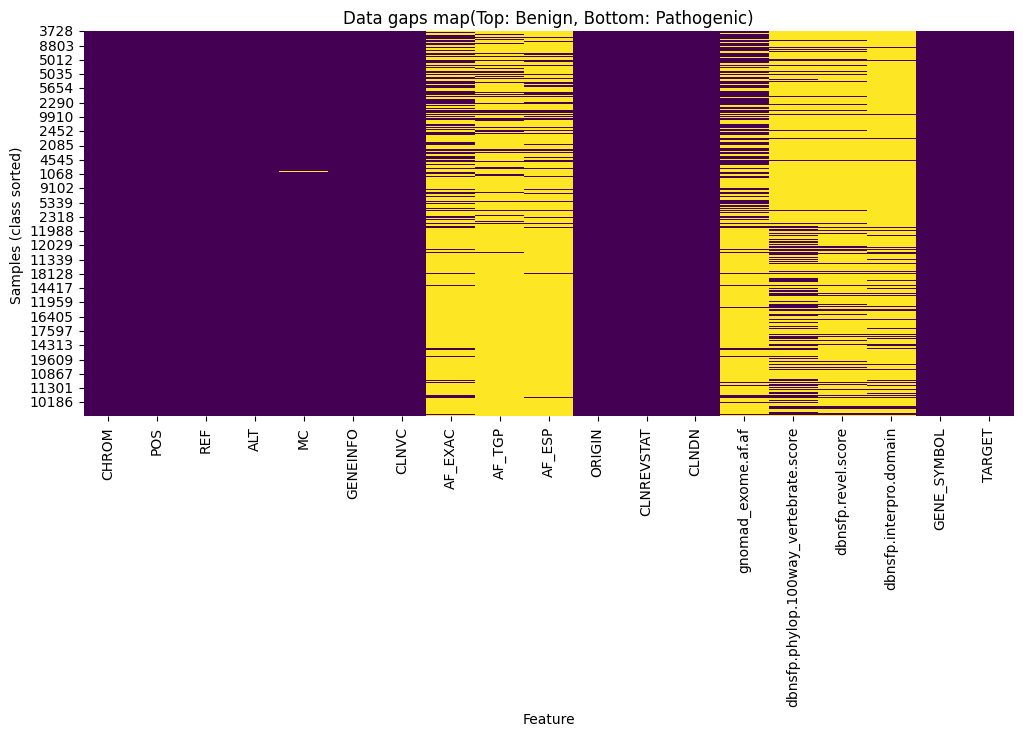

In [42]:
plt.figure(figsize=(12, 5))

sns.heatmap(X_train_eda.sort_values('TARGET').isnull(), cbar=False, cmap='viridis')
plt.title("Data gaps map(Top: Benign, Bottom: Pathogenic)")
plt.xlabel("Feature")
plt.ylabel("Samples (class sorted)")
plt.show()

In [43]:
X_train_eda['DIFF_LEN'] = X_train_eda['ALT'].str.len() - X_train_eda['REF'].str.len()

In [44]:
X_train_eda['DIFF_LEN'].value_counts()

DIFF_LEN
 0       12052
-1        1482
 1         757
-2         465
-4         190
         ...  
-130         1
-5930        1
-91          1
 1992        1
-1257        1
Name: count, Length: 161, dtype: int64

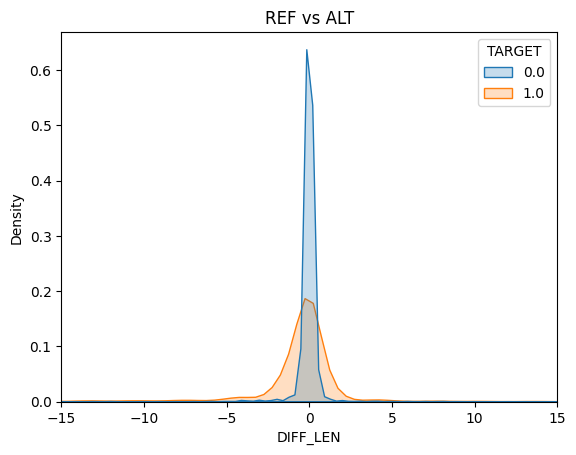

In [45]:
sns.kdeplot(data=X_train_eda[X_train_eda['DIFF_LEN'].between(-50, 50)],
            x='DIFF_LEN', hue='TARGET', fill=True)
plt.title("REF vs ALT")
plt.xlim(-15, 15)
plt.show()

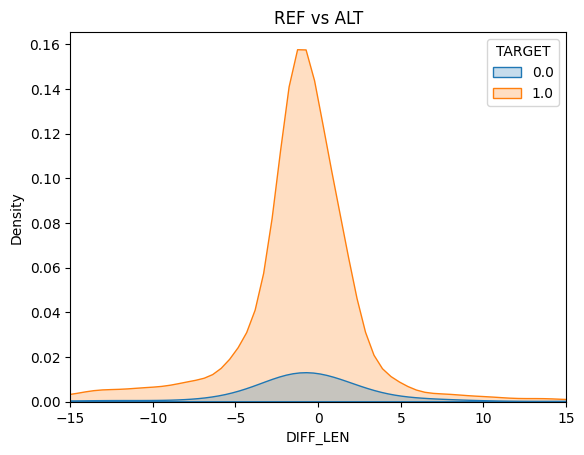

In [46]:
df_indel = X_train_eda[X_train_eda['DIFF_LEN'] != 0]
sns.kdeplot(data=df_indel[df_indel['DIFF_LEN'].between(-50, 50)],
            x='DIFF_LEN', hue='TARGET', fill=True)
plt.title("REF vs ALT")
plt.xlim(-15,15)
plt.show()

In [47]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  object 
 1   POS                                    16000 non-null  object 
 2   REF                                    16000 non-null  object 
 3   ALT                                    16000 non-null  object 
 4   MC                                     15903 non-null  object 
 5   GENEINFO                               15999 non-null  object 
 6   CLNVC                                  16000 non-null  object 
 7   AF_EXAC                                3075 non-null   object 
 8   AF_TGP                                 1939 non-null   object 
 9   AF_ESP                                 1441 non-null   object 
 10  ORIGIN                                 16000 non-null  object 
 11  CLNR

In [48]:
X_train_eda['CHROM'].value_counts()

CHROM
2     1663
1     1254
17    1078
11     988
X      870
3      843
16     823
5      789
7      727
6      727
19     714
9      667
12     650
15     603
10     560
8      529
4      527
14     444
13     426
22     360
20     292
18     264
21     186
MT      14
Y        2
Name: count, dtype: int64

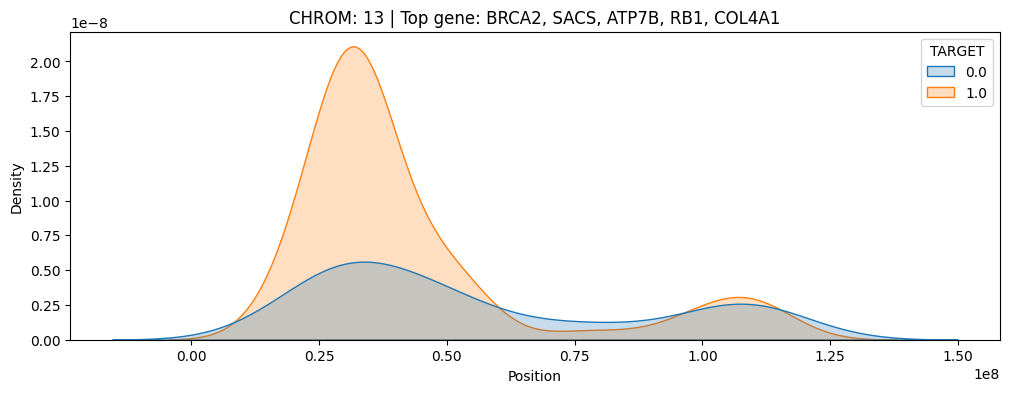

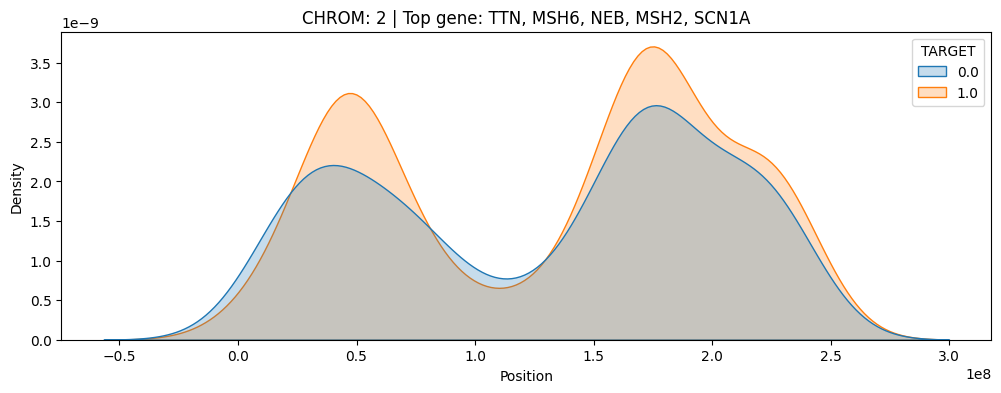

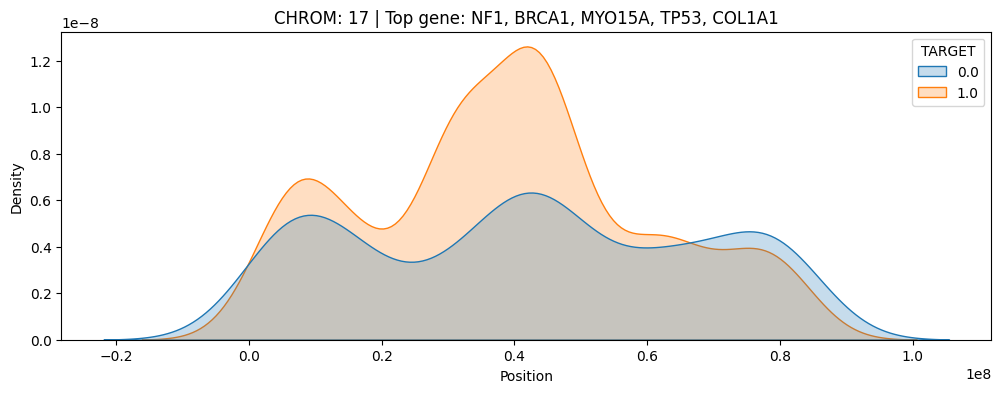

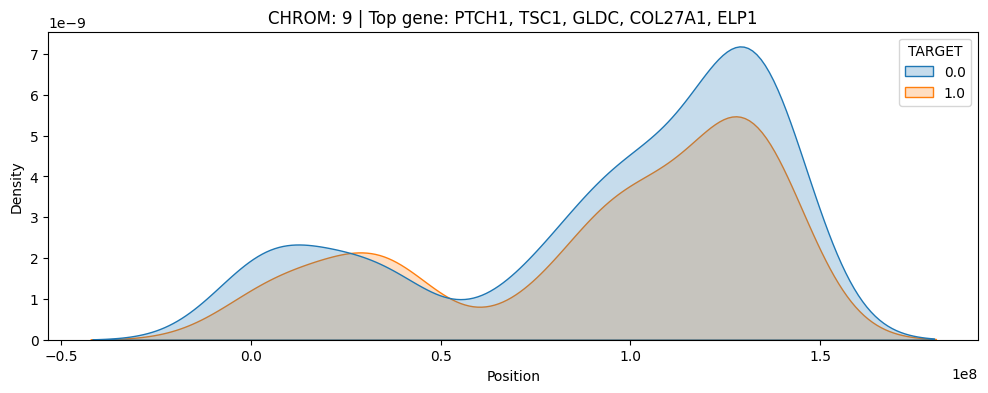

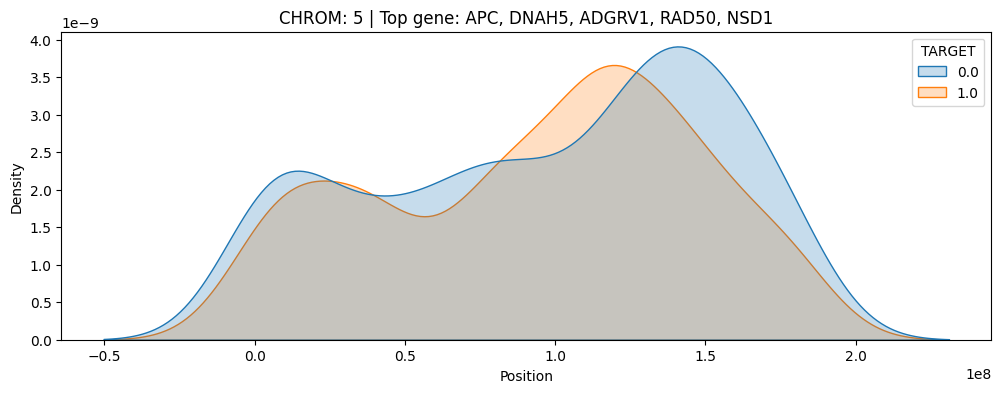

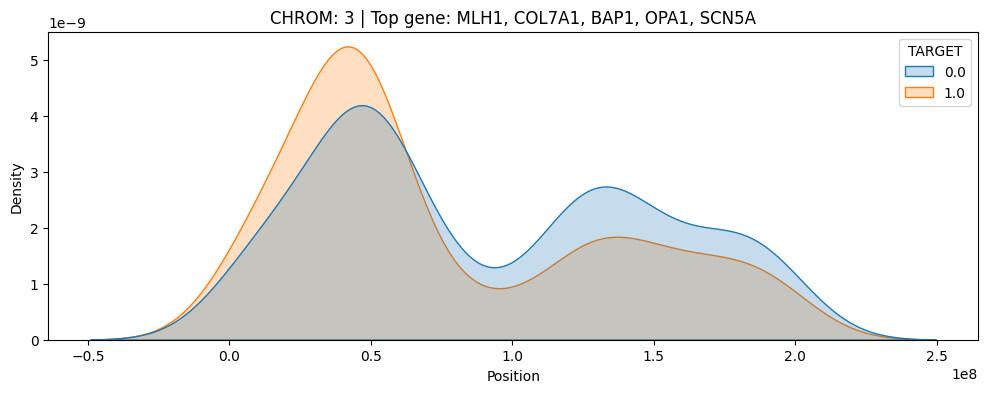

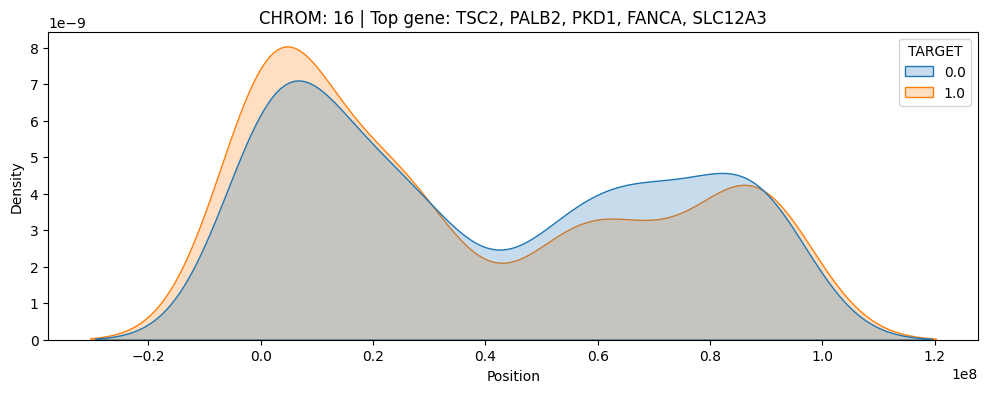

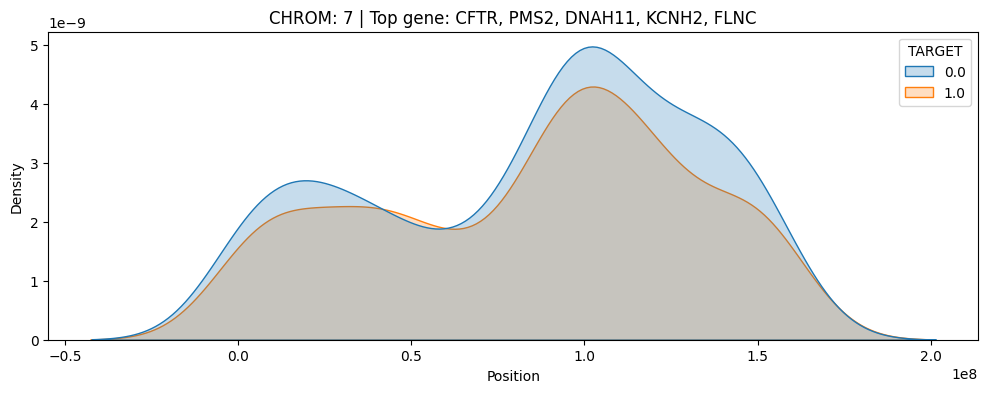

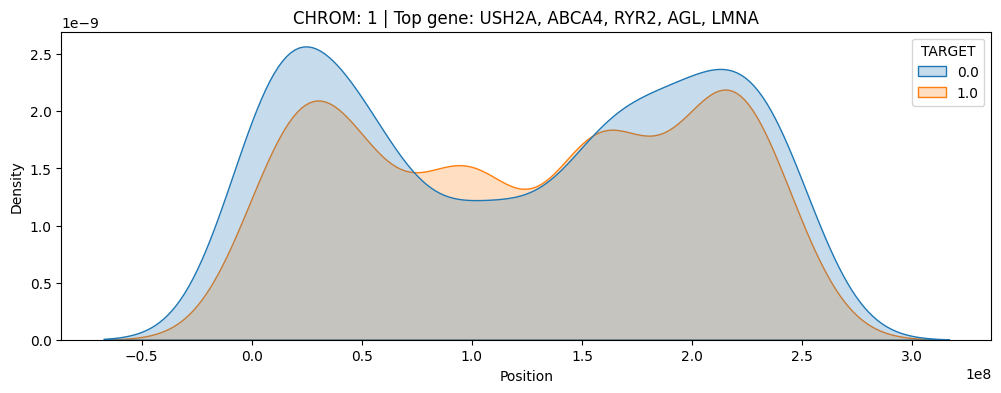

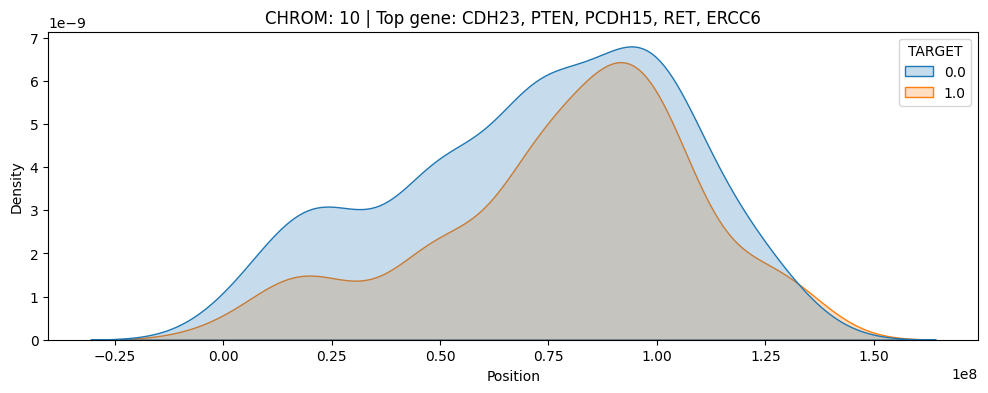

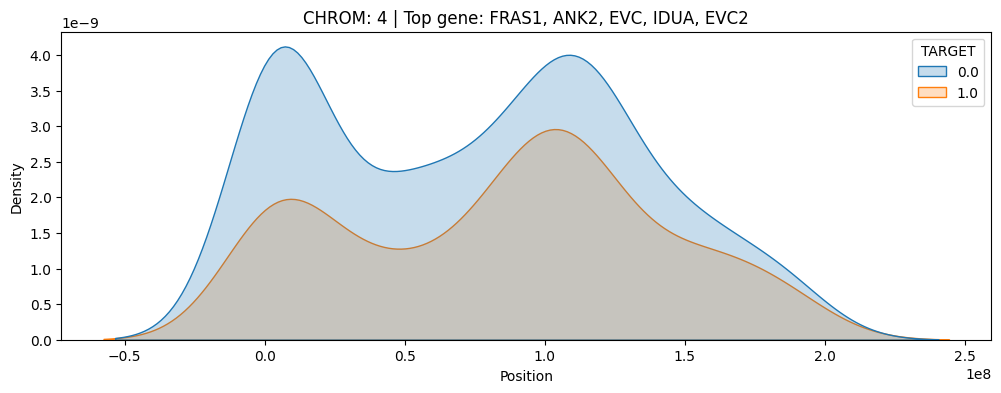

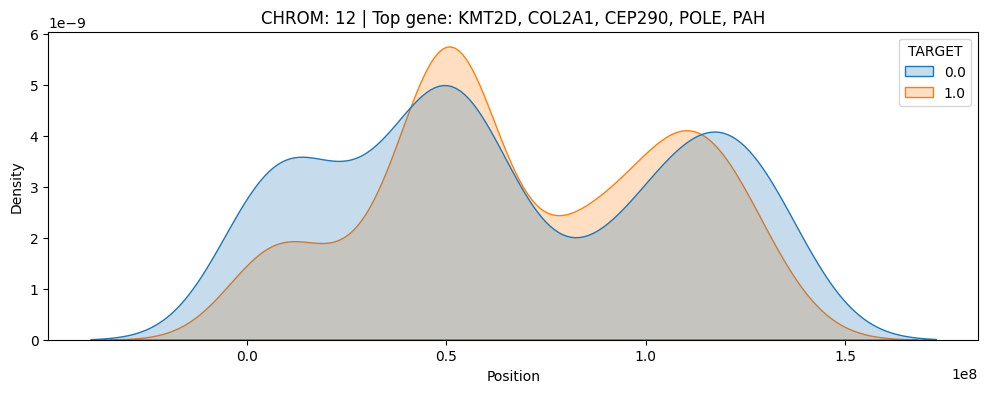

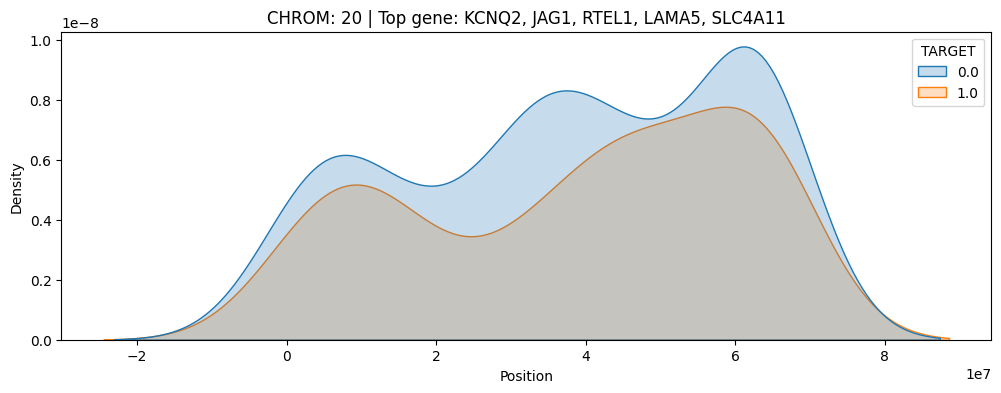

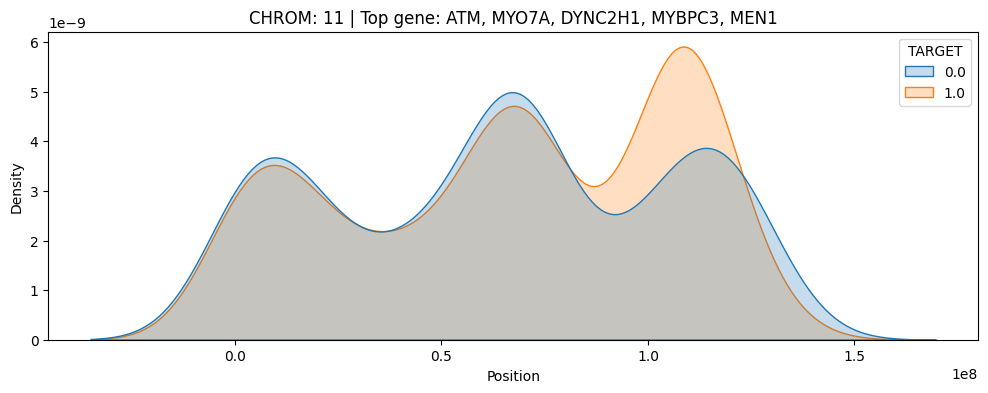

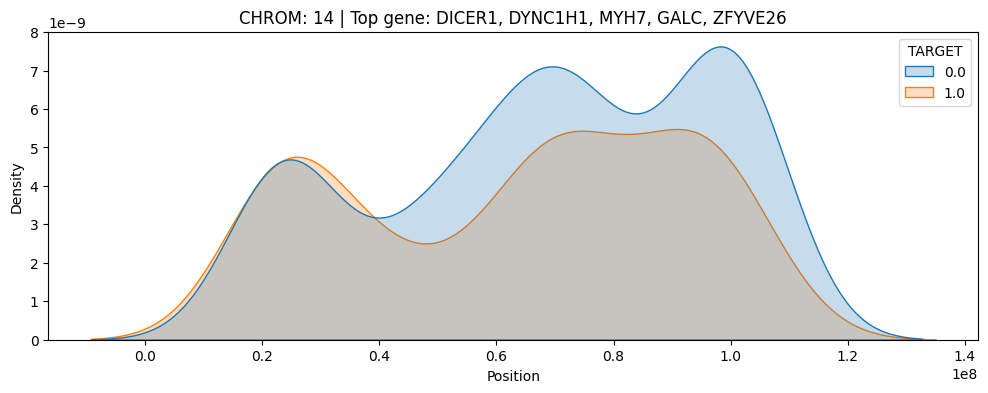

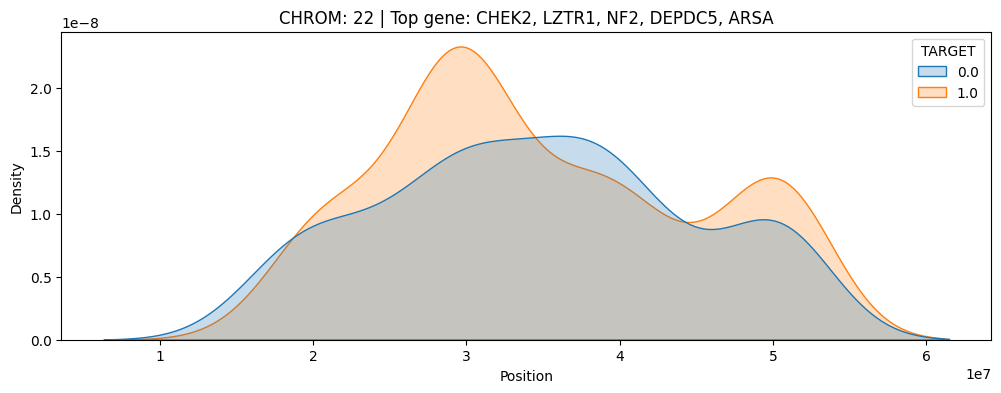

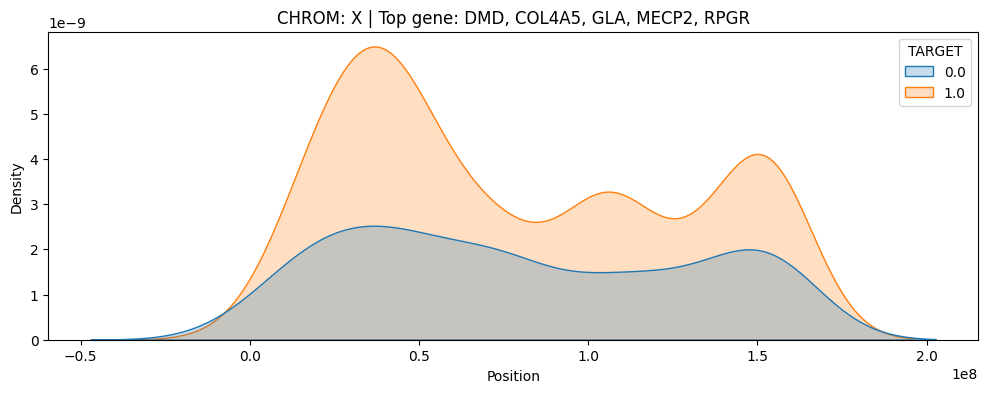

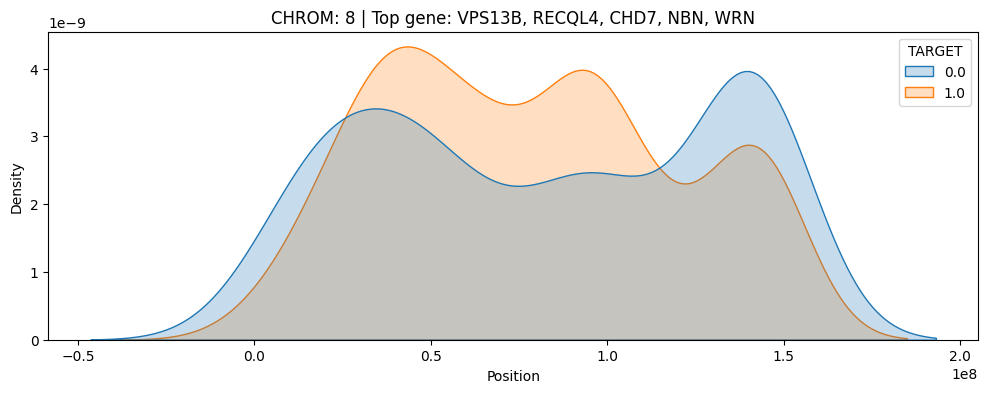

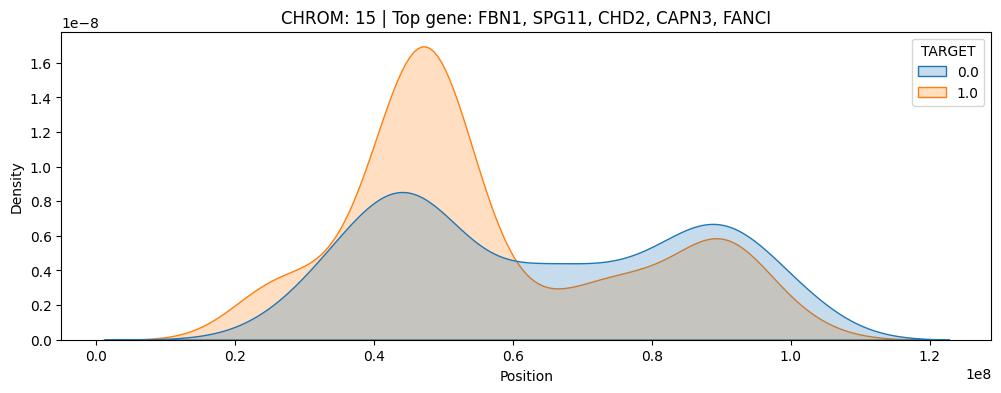

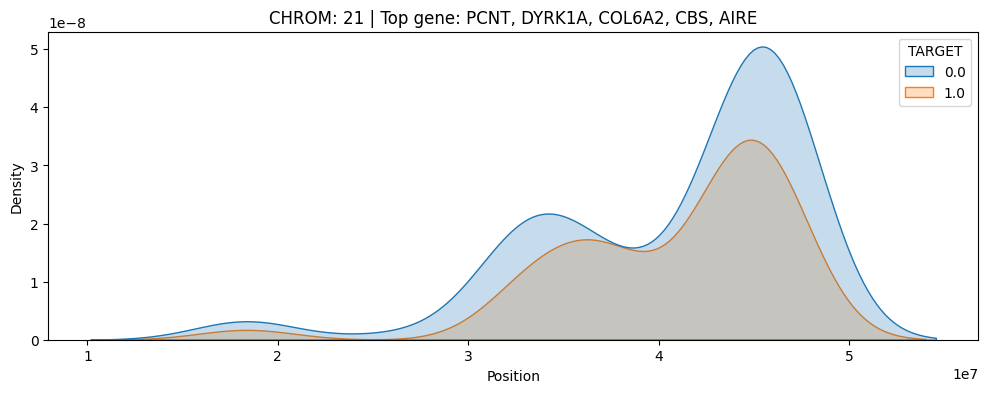

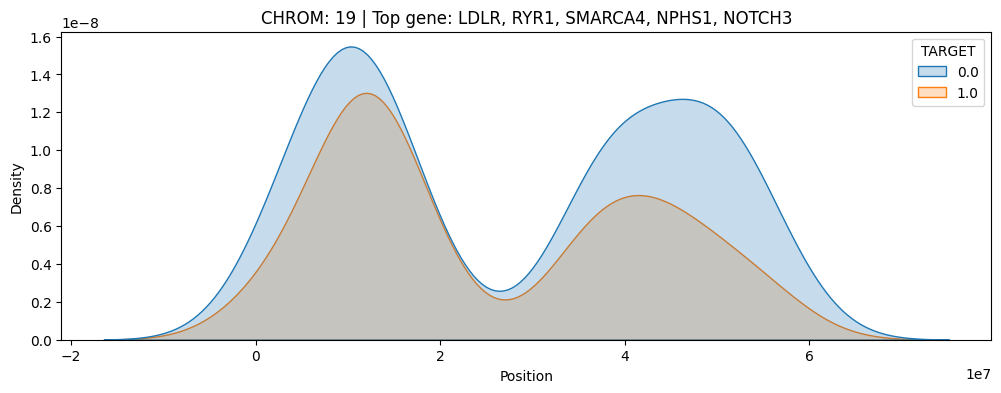

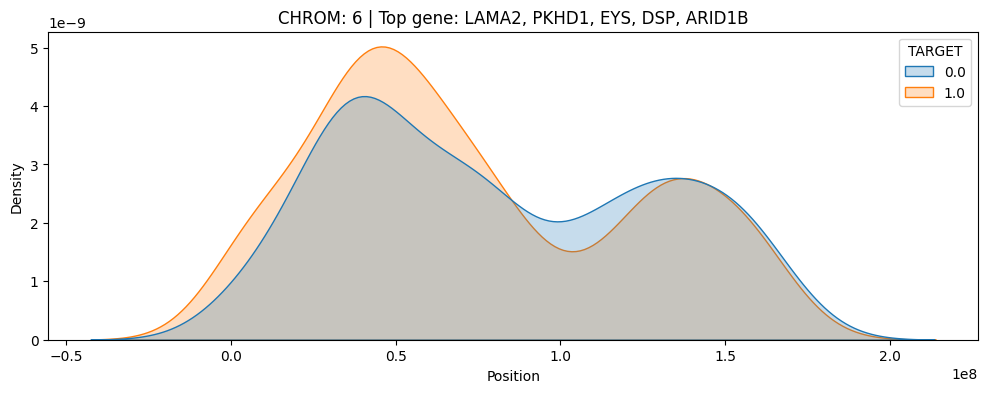

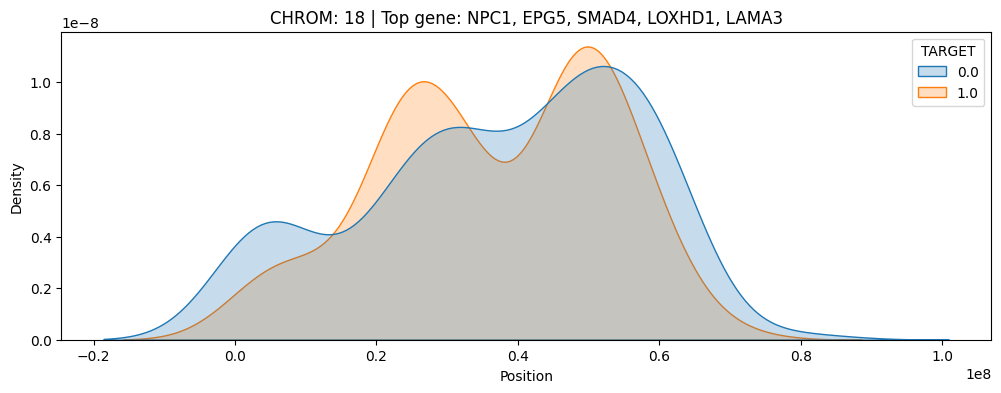

In [49]:
chroms_list = X_train_eda['CHROM'].unique().tolist()
X_train_eda['POS'] = pd.to_numeric(X_train_eda['POS'], errors='coerce')

for chrom in chroms_list: 
    subset = X_train_eda[X_train_eda['CHROM'] == chrom]
    if len(subset) < 50:
        continue
    plt.figure(figsize=(12, 4))
    sns.kdeplot(data=subset, x='POS', hue='TARGET', fill=True)
    top_genes = subset['GENE_SYMBOL'].value_counts().head().index.to_list()  
    plt.title(f'CHROM: {chrom} | Top gene: {", ".join(map(str, top_genes))}')
    plt.ylabel('Density')
    plt.xlabel('Position')
    plt.show()

In [50]:
X_train_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  object 
 1   POS                                    16000 non-null  int64  
 2   REF                                    16000 non-null  object 
 3   ALT                                    16000 non-null  object 
 4   MC                                     15903 non-null  object 
 5   GENEINFO                               15999 non-null  object 
 6   CLNVC                                  16000 non-null  object 
 7   AF_EXAC                                3075 non-null   object 
 8   AF_TGP                                 1939 non-null   object 
 9   AF_ESP                                 1441 non-null   object 
 10  ORIGIN                                 16000 non-null  object 
 11  CLNR

In [51]:
X_train_eda['is_frameshift'] = (X_train_eda['DIFF_LEN'] % 3 != 0).astype(int)

In [52]:
X_train_eda['is_frameshift'].value_counts()

is_frameshift
0    12272
1     3728
Name: count, dtype: int64

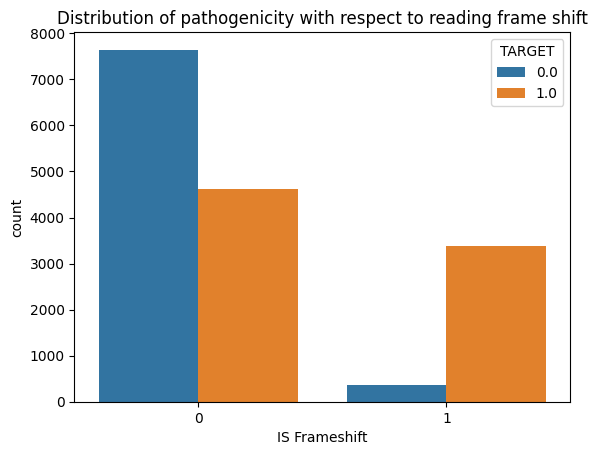

In [53]:
sns.countplot(data=X_train_eda, x='is_frameshift', hue='TARGET', fill=True)
plt.title('Distribution of pathogenicity with respect to reading frame shift')
plt.xlabel('IS Frameshift')
plt.show()

In [54]:
X_train_eda.head(15)

,CHROM,POS,REF,ALT,MC,GENEINFO,CLNVC,AF_EXAC,AF_TGP,AF_ESP,...,CLNREVSTAT,CLNDN,gnomad_exome.af.af,dbnsfp.phylop.100way_vertebrate.score,dbnsfp.revel.score,dbnsfp.interpro.domain,GENE_SYMBOL,TARGET,DIFF_LEN,is_frameshift
13500,13,32337642,A,AT,SO:0001587|nonsense,BRCA2:675,Duplication,NaN,NaN,NaN,...,reviewed_by_expert_panel,"Breast-ovarian_cancer,_familial,_susceptibilit...",NaN,NaN,NaN,NaN,BRCA2,1.0,1,1
4606,2,71568098,C,G,SO:0001627|intron_variant,DYSF:8291,single_nucleotide_variant,NaN,NaN,NaN,...,"criteria_provided,_single_submitter",Neuromuscular_disease_caused_by_qualitative_or...,NaN,NaN,NaN,NaN,DYSF,0.0,0,0
5079,17,50056448,C,G,SO:0001819|synonymous_variant,ITGA3:3675,single_nucleotide_variant,NaN,NaN,NaN,...,"criteria_provided,_single_submitter",not_provided,NaN,NaN,NaN,NaN,ITGA3,0.0,0,0
11798,9,95111630,C,A,SO:0001587|nonsense,FANCC:2176|AOPEP:84909,single_nucleotide_variant,NaN,NaN,NaN,...,"criteria_provided,_multiple_submitters,_no_con...",FANCC-related_disorder|Fanconi_anemia|Fanconi_...,0.000008,-0.463,NaN,NaN,FANCC,1.0,0,0
19966,5,177292150,G,C,SO:0001583|missense_variant,NSD1:64324,single_nucleotide_variant,NaN,NaN,NaN,...,"criteria_provided,_single_submitter",not_provided,NaN,7.999,0.706,"Zinc finger, PHD-type",NSD1,1.0,0,0
842,3,58148824,T,C,SO:0001819|synonymous_variant,FLNB:2317,single_nucleotide_variant,NaN,NaN,NaN,...,"criteria_provided,_single_submitter",not_provided,0.000008,NaN,NaN,NaN,FLNB,0.0,0,0
15329,16,88836222,G,C,SO:0001583|missense_variant,GALNS:2588,single_nucleotide_variant,NaN,NaN,NaN,...,"criteria_provided,_single_submitter","Mucopolysaccharidosis,_MPS-IV-A",NaN,3.888,0.417,"[Sulfatase, N-terminal, Sulfatase, N-terminal]",GALNS,1.0,0,0
8299,7,91941158,C,T,SO:0001627|intron_variant,AKAP9:10142,single_nucleotide_variant,NaN,NaN,NaN,...,"criteria_provided,_single_submitter",Long_QT_syndrome,NaN,-0.313,NaN,NaN,AKAP9,0.0,0,0
11850,1,21577470,C,T,SO:0001583|missense_variant,ALPL:249,single_nucleotide_variant,NaN,NaN,NaN,...,"criteria_provided,_single_submitter",Hypophosphatasia,NaN,7.474,0.945,NaN,ALPL,1.0,0,0
9895,16,2110490,C,T,SO:0001819|synonymous_variant,PKD1:5310,single_nucleotide_variant,NaN,NaN,NaN,...,no_assertion_criteria_provided,PKD1-related_disorder,0.000117,NaN,NaN,NaN,PKD1,0.0,0,0


In [55]:
X_train_eda['MC'] = X_train_eda['MC'].str.extract(r'\|(\S*)')

In [56]:
X_train_eda['MC'].value_counts()

MC
synonymous_variant                                                                                                                                  3058
intron_variant                                                                                                                                      2926
frameshift_variant                                                                                                                                  2218
missense_variant                                                                                                                                    1955
nonsense                                                                                                                                            1353
                                                                                                                                                    ... 
missense_variant,SO:0001619|non-coding_transcript_variant,SO:0001623|5_prime_UT

In [57]:
X_train_eda['MC'] = X_train_eda['MC'].str.replace(r',[^|]*', '', regex=True)

In [58]:
X_train_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 21 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  object 
 1   POS                                    16000 non-null  int64  
 2   REF                                    16000 non-null  object 
 3   ALT                                    16000 non-null  object 
 4   MC                                     15903 non-null  object 
 5   GENEINFO                               15999 non-null  object 
 6   CLNVC                                  16000 non-null  object 
 7   AF_EXAC                                3075 non-null   object 
 8   AF_TGP                                 1939 non-null   object 
 9   AF_ESP                                 1441 non-null   object 
 10  ORIGIN                                 16000 non-null  object 
 11  CLNR

In [59]:
pd.set_option("display.max_rows", None)

X_train_eda['MC'].value_counts()

MC
synonymous_variant                                                                                      3058
intron_variant                                                                                          2926
frameshift_variant                                                                                      2218
missense_variant                                                                                        1955
nonsense                                                                                                1353
splice_donor_variant                                                                                     565
splice_acceptor_variant                                                                                  451
non-coding_transcript_variant|synonymous_variant                                                         436
frameshift_variant|non-coding_transcript_variant                                                         300
missense_variant

In [60]:
def calc_impact_score(mc_string):
    if pd.isna(mc_string):
        return np.nan
    s = mc_string.lower()
    high_impact_keyword = ['nonsense', 'frameshift', 'splice_acceptor', 'splice_donor', 'start_lost', 'stop_lost', 'initiator_codon']
    if any(keyword in s for keyword in high_impact_keyword):
        return 2
    medium_impact_keyword = ['missense', 'inframe', 'protein_altering']
    if any(keyword in s for keyword in medium_impact_keyword):
        return 1
    return 0

X_train_eda['MC_IMPACT_SCORE'] = X_train_eda['MC'].apply(calc_impact_score)

In [61]:
X_train_eda['MC_IMPACT_SCORE'].value_counts()

MC_IMPACT_SCORE
0.0    7196
2.0    6100
1.0    2607
Name: count, dtype: int64

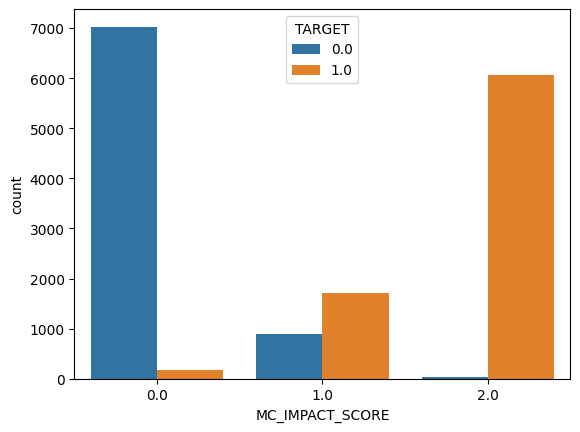

In [62]:
sns.countplot(data=X_train_eda, x='MC_IMPACT_SCORE', hue='TARGET', fill=True)
plt.xlabel('MC_IMPACT_SCORE')
plt.show()

In [63]:
cond_AG = (X_train_eda['REF'] == 'A') & (X_train_eda['ALT'] == 'G')
cond_GA = (X_train_eda['REF'] == 'G') & (X_train_eda['ALT'] == 'A')
cond_CT = (X_train_eda['REF'] == 'C') & (X_train_eda['ALT'] == 'T')
cond_TC = (X_train_eda['REF'] == 'T') & (X_train_eda['ALT'] == 'C')

X_train_eda['is_transition'] = (cond_AG | cond_GA | cond_CT | cond_TC).astype(int)

In [64]:
X_train_eda['is_transition'].value_counts()

is_transition
0    8166
1    7834
Name: count, dtype: int64

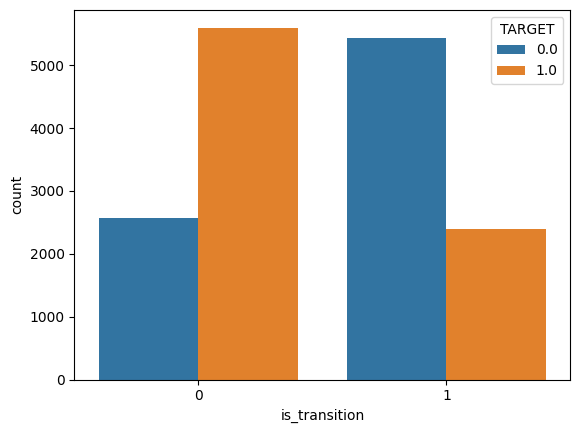

In [65]:
sns.countplot(data=X_train_eda, x='is_transition', hue='TARGET', fill=True)
plt.xlabel('is_transition')
plt.show()

In [66]:
X_train_eda = X_train_eda.drop(columns=['CLNREVSTAT', 'CLNDN'], axis=1)

In [67]:
X_train_eda['GENE_SYMBOL'].value_counts()

GENE_SYMBOL
TTN            228
BRCA2          185
NF1            142
ATM            126
BRCA1          123
FBN1           109
MSH6            96
APC             87
USH2A           85
NEB             74
MSH2            69
DMD             68
TSC2            67
MLH1            59
LDLR            56
SCN1A           54
KMT2D           54
DNAH5           52
PALB2           49
COL7A1          48
PKD1            47
COL4A5          47
PKHD1           46
LAMA2           46
RYR1            46
ABCA4           46
DYSF            43
FANCA           42
ADGRV1          42
EYS             41
CHEK2           41
CFTR            41
ALMS1           40
PMS2            40
COL4A4          39
MYO7A           37
DSP             37
VPS13B          37
DNAH11          37
TP53            36
MYO15A          36
SACS            34
ATP7B           33
COL1A1          32
DICER1          32
PTCH1           32
ARID1B          32
RB1             32
TSC1            31
CDH23           31
PTEN            30
KCNH2           29


In [68]:
gene_stats = X_train_eda.groupby('GENE_SYMBOL')['TARGET'].agg(['count', 'mean'])
global_mean = X_train_eda['TARGET'].mean()
m=10
smooth_map = (gene_stats['count'] * gene_stats['mean'] + m * global_mean) / (gene_stats['count'] + m)
X_train_eda['GENE_RISK'] = X_train_eda['GENE_SYMBOL'].map(smooth_map)
X_train_eda['GENE_RISK'] = X_train_eda['GENE_RISK'].fillna(global_mean)
X_train_eda = X_train_eda.drop(columns=['GENE_SYMBOL'], axis=1)

In [69]:
X_train_eda['GENE_RISK'].head(20)

13500    0.794872
4606     0.584906
5079     0.428571
11798    0.523810
19966    0.678571
842      0.380952
15329    0.611111
8299     0.227273
11850    0.678571
9895     0.771930
16271    0.545455
17777    0.448276
13638    0.480769
14126    0.771930
12399    0.578947
4010     0.606061
10166    0.596639
15033    0.500000
17114    0.545455
18486    0.461538
Name: GENE_RISK, dtype: float64

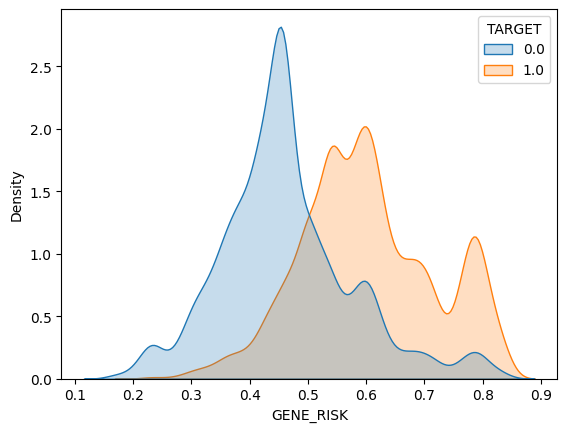

In [70]:
sns.kdeplot(data=X_train_eda, x='GENE_RISK', hue='TARGET', fill=True)
plt.show()

In [71]:
X_train_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 21 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  object 
 1   POS                                    16000 non-null  int64  
 2   REF                                    16000 non-null  object 
 3   ALT                                    16000 non-null  object 
 4   MC                                     15903 non-null  object 
 5   GENEINFO                               15999 non-null  object 
 6   CLNVC                                  16000 non-null  object 
 7   AF_EXAC                                3075 non-null   object 
 8   AF_TGP                                 1939 non-null   object 
 9   AF_ESP                                 1441 non-null   object 
 10  ORIGIN                                 16000 non-null  object 
 11  gnom

In [73]:
af_cols = ['AF_EXAC', 'AF_TGP', 'AF_ESP', 'gnomad_exome.af.af']
for col in af_cols:
    X_train_eda[col] = X_train_eda[col].fillna(0)
    X_train_eda[col] = pd.to_numeric(X_train_eda[col], errors='coerce')

X_train_eda['MAX_AF'] = X_train_eda[af_cols].max(axis=1)
X_train_eda = X_train_eda.drop(columns=af_cols, axis=1)

In [74]:
X_train_eda.head(20)

,CHROM,POS,REF,ALT,MC,GENEINFO,CLNVC,ORIGIN,dbnsfp.phylop.100way_vertebrate.score,dbnsfp.revel.score,dbnsfp.interpro.domain,TARGET,DIFF_LEN,is_frameshift,MC_IMPACT_SCORE,is_transition,GENE_RISK,MAX_AF
13500,13,32337642,A,AT,nonsense,BRCA2:675,Duplication,1,NaN,NaN,NaN,1.0,1,1,2.0,0,0.794872,0.000000
4606,2,71568098,C,G,intron_variant,DYSF:8291,single_nucleotide_variant,1,NaN,NaN,NaN,0.0,0,0,0.0,0,0.584906,0.000000
5079,17,50056448,C,G,synonymous_variant,ITGA3:3675,single_nucleotide_variant,1,NaN,NaN,NaN,0.0,0,0,0.0,0,0.428571,0.000000
11798,9,95111630,C,A,nonsense,FANCC:2176|AOPEP:84909,single_nucleotide_variant,1,-0.463,NaN,NaN,1.0,0,0,2.0,0,0.523810,0.000008
19966,5,177292150,G,C,missense_variant,NSD1:64324,single_nucleotide_variant,1,7.999,0.706,"Zinc finger, PHD-type",1.0,0,0,1.0,0,0.678571,0.000000
842,3,58148824,T,C,synonymous_variant,FLNB:2317,single_nucleotide_variant,1,NaN,NaN,NaN,0.0,0,0,0.0,1,0.380952,0.000008
15329,16,88836222,G,C,missense_variant,GALNS:2588,single_nucleotide_variant,1,3.888,0.417,"[Sulfatase, N-terminal, Sulfatase, N-terminal]",1.0,0,0,1.0,0,0.611111,0.000000
8299,7,91941158,C,T,intron_variant,AKAP9:10142,single_nucleotide_variant,1,-0.313,NaN,NaN,0.0,0,0,0.0,1,0.227273,0.000000
11850,1,21577470,C,T,missense_variant,ALPL:249,single_nucleotide_variant,1,7.474,0.945,NaN,1.0,0,0,1.0,1,0.678571,0.000000
9895,16,2110490,C,T,synonymous_variant,PKD1:5310,single_nucleotide_variant,1,NaN,NaN,NaN,0.0,0,0,0.0,1,0.771930,0.000117


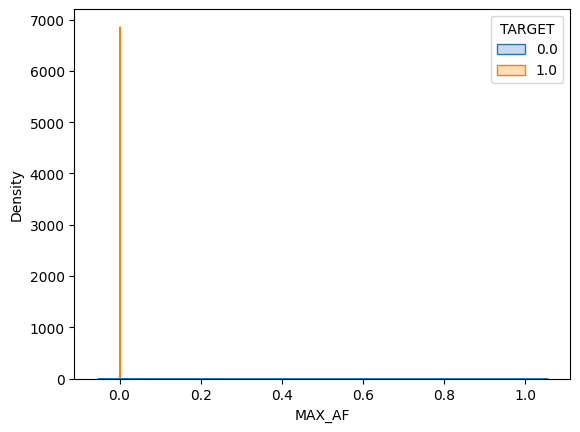

In [75]:
sns.kdeplot(data=X_train_eda, x='MAX_AF', hue='TARGET', fill=True)
plt.show()

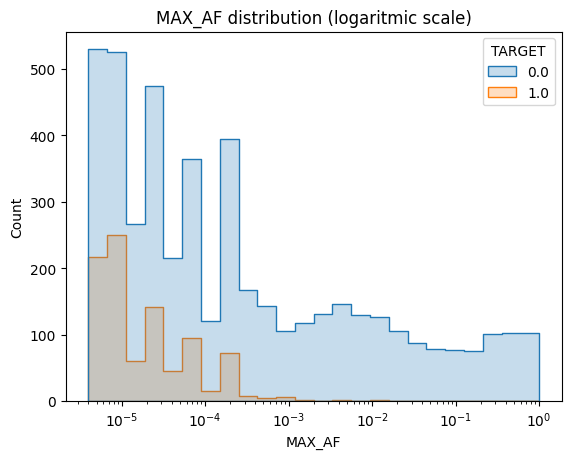

In [76]:
sns.histplot(data=X_train_eda, x='MAX_AF', hue='TARGET', log_scale=True, element="step")
plt.title("MAX_AF distribution (logaritmic scale)")
plt.show()

In [77]:
X_train_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  object 
 1   POS                                    16000 non-null  int64  
 2   REF                                    16000 non-null  object 
 3   ALT                                    16000 non-null  object 
 4   MC                                     15903 non-null  object 
 5   GENEINFO                               15999 non-null  object 
 6   CLNVC                                  16000 non-null  object 
 7   ORIGIN                                 16000 non-null  object 
 8   dbnsfp.phylop.100way_vertebrate.score  5203 non-null   float64
 9   dbnsfp.revel.score                     2487 non-null   float64
 10  dbnsfp.interpro.domain                 1914 non-null   object 
 11  TARG

In [78]:
X_train_eda['CHROM'].value_counts()

CHROM
2     1663
1     1254
17    1078
11     988
X      870
3      843
16     823
5      789
7      727
6      727
19     714
9      667
12     650
15     603
10     560
8      529
4      527
14     444
13     426
22     360
20     292
18     264
21     186
MT      14
Y        2
Name: count, dtype: int64

In [79]:
chrom_map = {
    'X': 23,
    'Y': 24,
    'MT': 25, 
    'M': 25,
    'Mit': 25,
    'NT_187693.1': 99
}
X_train_eda['CHROM'] = X_train_eda['CHROM'].astype(str).replace(chrom_map)


In [80]:
X_train_eda['CHROM'] = X_train_eda['CHROM'].astype(int)

In [81]:
X_train_eda = X_train_eda.drop(columns=['POS', 'REF', 'ALT', 'MC', 'GENEINFO', 'CLNVC'], axis=1)

In [82]:
X_train_eda['ORIGIN'].value_counts()

ORIGIN
1     14579
0       687
32      207
33       99
4        93
5        76
16       50
17       39
3        35
8        30
9        23
2        21
64       15
65       10
49        5
35        5
25        4
13        3
19        2
24        2
11        2
21        2
73        1
20        1
85        1
29        1
34        1
48        1
57        1
37        1
89        1
41        1
7         1
Name: count, dtype: int64

In [83]:
top_origins = X_train_eda['ORIGIN'].value_counts()
common_origin = top_origins[top_origins >= 50].index
X_train_eda['ORIGIN_GROUPED'] = X_train_eda['ORIGIN'].apply(lambda x: x if x in common_origin else 999)

X_train_eda = pd.get_dummies(X_train_eda, columns=['ORIGIN_GROUPED'], prefix='ORIGIN')
if 'ORIGIN' in X_train_eda.columns:
    X_train_eda = X_train_eda.drop(columns=['ORIGIN'])

In [84]:
X_train_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 19 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  int64  
 1   dbnsfp.phylop.100way_vertebrate.score  5203 non-null   float64
 2   dbnsfp.revel.score                     2487 non-null   float64
 3   dbnsfp.interpro.domain                 1914 non-null   object 
 4   TARGET                                 16000 non-null  float64
 5   DIFF_LEN                               16000 non-null  int64  
 6   is_frameshift                          16000 non-null  int64  
 7   MC_IMPACT_SCORE                        15903 non-null  float64
 8   is_transition                          16000 non-null  int64  
 9   GENE_RISK                              16000 non-null  float64
 10  MAX_AF                                 16000 non-null  float64
 11  ORIG

In [85]:
X_train_eda['is_in_critical_domain'] = X_train_eda['dbnsfp.interpro.domain'].notna().astype(int)
X_train_eda = X_train_eda.drop(columns=['dbnsfp.interpro.domain'], axis=1)

score_cols = ['dbnsfp.phylop.100way_vertebrate.score', 'dbnsfp.revel.score']
X_train_eda[score_cols] = X_train_eda[score_cols].fillna(-1)

In [86]:
X_train_eda['MC_IMPACT_SCORE'] = X_train_eda['MC_IMPACT_SCORE'].fillna(0)
X_train_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 19 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  int64  
 1   dbnsfp.phylop.100way_vertebrate.score  16000 non-null  float64
 2   dbnsfp.revel.score                     16000 non-null  float64
 3   TARGET                                 16000 non-null  float64
 4   DIFF_LEN                               16000 non-null  int64  
 5   is_frameshift                          16000 non-null  int64  
 6   MC_IMPACT_SCORE                        16000 non-null  float64
 7   is_transition                          16000 non-null  int64  
 8   GENE_RISK                              16000 non-null  float64
 9   MAX_AF                                 16000 non-null  float64
 10  ORIGIN_999                             16000 non-null  bool   
 11  ORIG

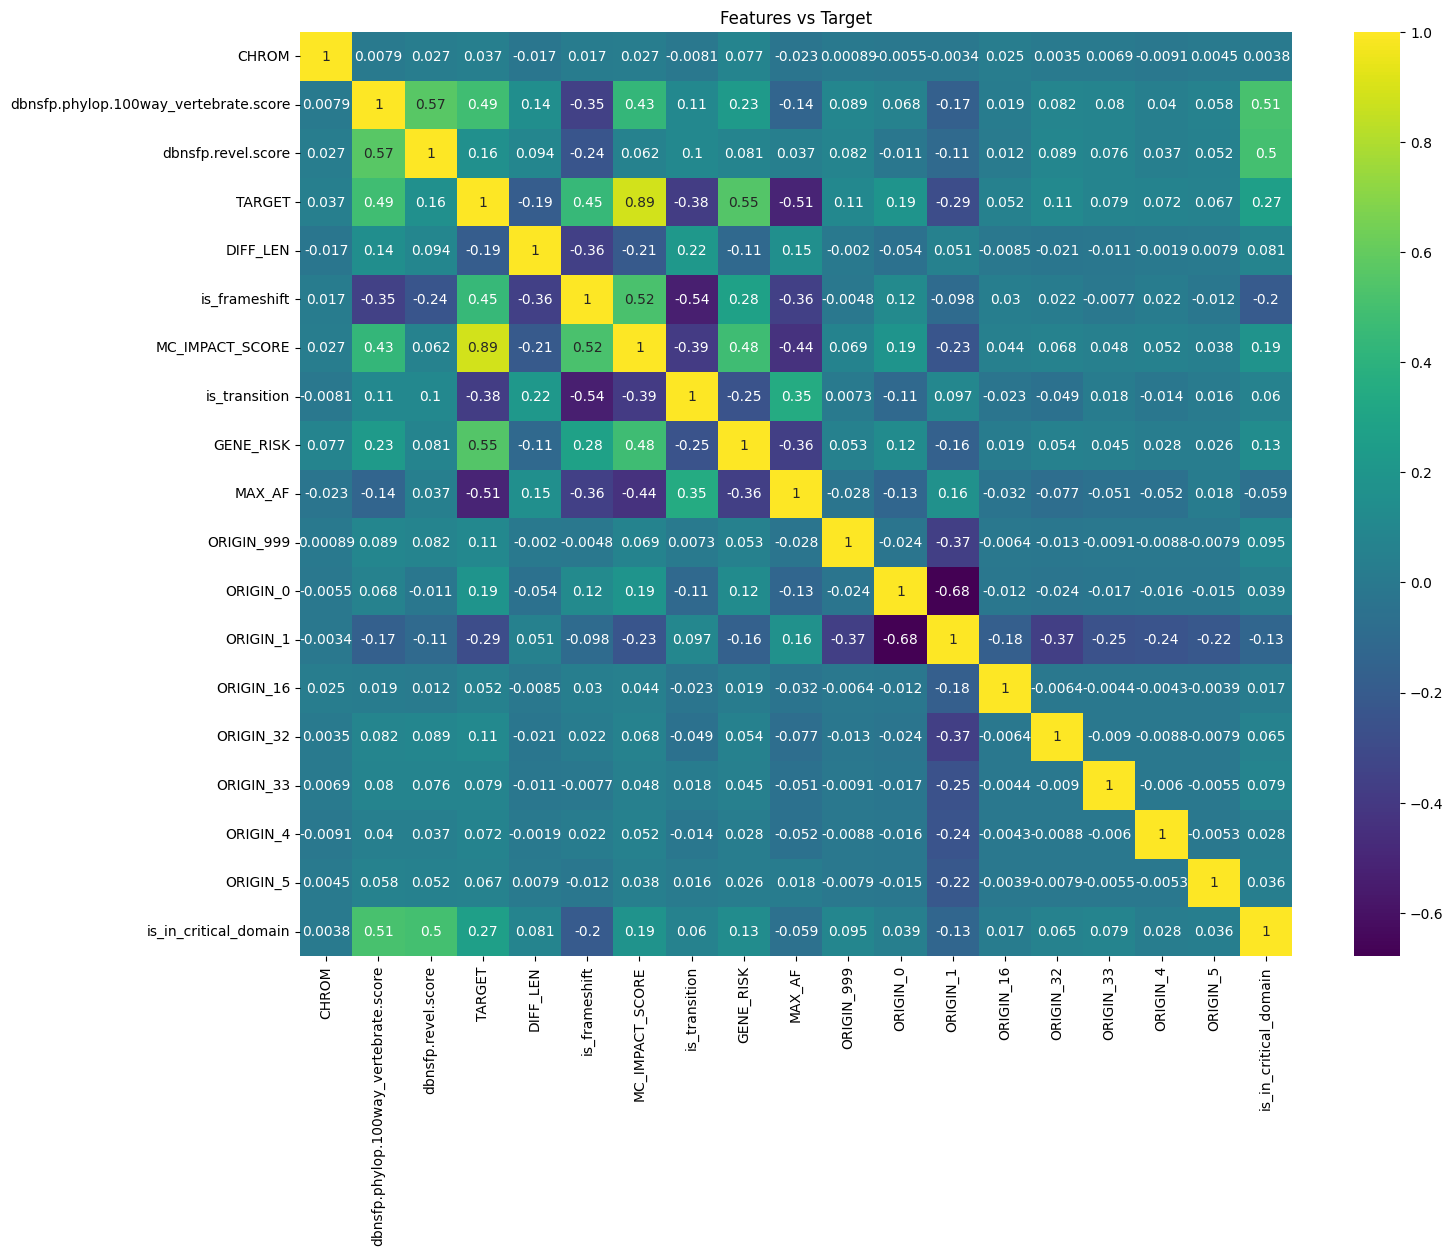

In [87]:
corr_matrix = X_train_eda.corr(method='spearman')
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='viridis')
plt.title('Features vs Target')
plt.show()

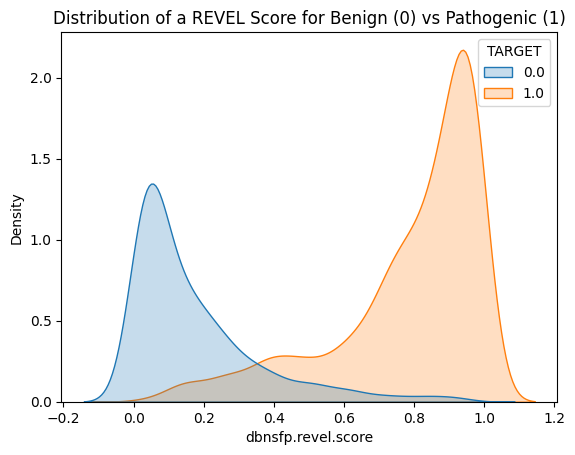

In [88]:
sns.kdeplot(data=X_train_eda[X_train_eda['dbnsfp.revel.score'] != -1], 
            x='dbnsfp.revel.score', hue='TARGET', fill=True)
plt.title("Distribution of a REVEL Score for Benign (0) vs Pathogenic (1)")
plt.show()

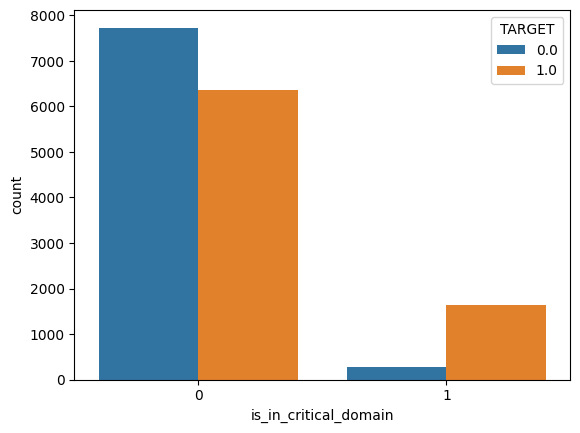

In [89]:
sns.countplot(data=X_train_eda, x='is_in_critical_domain', hue='TARGET')
plt.show()

In [90]:
X_train_eda.head()

,CHROM,dbnsfp.phylop.100way_vertebrate.score,dbnsfp.revel.score,TARGET,DIFF_LEN,is_frameshift,MC_IMPACT_SCORE,is_transition,GENE_RISK,MAX_AF,ORIGIN_999,ORIGIN_0,ORIGIN_1,ORIGIN_16,ORIGIN_32,ORIGIN_33,ORIGIN_4,ORIGIN_5,is_in_critical_domain
13500,13,-1.000,-1.000,1.0,1,1,2.0,0,0.794872,0.000000,False,False,True,False,False,False,False,False,0
4606,2,-1.000,-1.000,0.0,0,0,0.0,0,0.584906,0.000000,False,False,True,False,False,False,False,False,0
5079,17,-1.000,-1.000,0.0,0,0,0.0,0,0.428571,0.000000,False,False,True,False,False,False,False,False,0
11798,9,-0.463,-1.000,1.0,0,0,2.0,0,0.523810,0.000008,False,False,True,False,False,False,False,False,0
19966,5,7.999,0.706,1.0,0,0,1.0,0,0.678571,0.000000,False,False,True,False,False,False,False,False,1


In [91]:
origin_cols = ['ORIGIN_0','ORIGIN_1','ORIGIN_4', 'ORIGIN_5', 'ORIGIN_32', 'ORIGIN_33', 'ORIGIN_999']
X_train_eda[origin_cols] = X_train_eda[origin_cols].astype(int)

In [92]:
X_train_eda.head()

,CHROM,dbnsfp.phylop.100way_vertebrate.score,dbnsfp.revel.score,TARGET,DIFF_LEN,is_frameshift,MC_IMPACT_SCORE,is_transition,GENE_RISK,MAX_AF,ORIGIN_999,ORIGIN_0,ORIGIN_1,ORIGIN_16,ORIGIN_32,ORIGIN_33,ORIGIN_4,ORIGIN_5,is_in_critical_domain
13500,13,-1.000,-1.000,1.0,1,1,2.0,0,0.794872,0.000000,0,0,1,False,0,0,0,0,0
4606,2,-1.000,-1.000,0.0,0,0,0.0,0,0.584906,0.000000,0,0,1,False,0,0,0,0,0
5079,17,-1.000,-1.000,0.0,0,0,0.0,0,0.428571,0.000000,0,0,1,False,0,0,0,0,0
11798,9,-0.463,-1.000,1.0,0,0,2.0,0,0.523810,0.000008,0,0,1,False,0,0,0,0,0
19966,5,7.999,0.706,1.0,0,0,1.0,0,0.678571,0.000000,0,0,1,False,0,0,0,0,1


In [93]:
X_train_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 19 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  int64  
 1   dbnsfp.phylop.100way_vertebrate.score  16000 non-null  float64
 2   dbnsfp.revel.score                     16000 non-null  float64
 3   TARGET                                 16000 non-null  float64
 4   DIFF_LEN                               16000 non-null  int64  
 5   is_frameshift                          16000 non-null  int64  
 6   MC_IMPACT_SCORE                        16000 non-null  float64
 7   is_transition                          16000 non-null  int64  
 8   GENE_RISK                              16000 non-null  float64
 9   MAX_AF                                 16000 non-null  float64
 10  ORIGIN_999                             16000 non-null  int64  
 11  ORIG

In [94]:
X_train_eda['MC_IMPACT_SCORE'].value_counts()

MC_IMPACT_SCORE
0.0    7293
2.0    6100
1.0    2607
Name: count, dtype: int64

In [95]:
X_train_eda['is_in_critical_domain'].value_counts()

is_in_critical_domain
0    14086
1     1914
Name: count, dtype: int64

In [98]:
class AddAcmgRules(BaseEstimator, TransformerMixin):
    def __init__(self, af_threshold_benign=0.05, revel_threshold_pathogenic=0.75):
        self.af_threshold_benign = af_threshold_benign
        self.revel_threshold_pathogenic = revel_threshold_pathogenic
        

    def fit(self, X, y=None):
        return self
    
    def _apply_population_rules(self, df):
        df['ACMG_BA1'] = (df['MAX_AF'] > self.af_threshold_benign).astype(int)
        df['ACMG_BS1'] = ((df['MAX_AF'] > 0.01) & (df['MAX_AF'] <= self.af_threshold_benign)).astype(int)
        df['ACMG_PM2'] = (df['MAX_AF'] < 0.0001).astype(int)
        return df
    
    def _apply_structural_rules(self, df):
        df['ACMG_PSV1'] = (df['MC_IMPACT_SCORE'] == 2.0).astype(int)
        df['ACMG_PM4'] = ((df['DIFF_LEN'] != 0) & (df['is_frameshift'] == 0) & (df['MC_IMPACT_SCORE'] != 2.0)).astype(int)
        return df
    
    def _apply_computational_rules(self, df):
        col = 'dbnsfp.revel.score'
        df['ACMG_PP3'] = ((df[col] > self.revel_threshold_pathogenic) & (df[col] != -1)).astype(int)
        return df
    
    def _apply_domain_rules(self, df):
        df['ACMG_PM1'] = df['is_in_critical_domain']
        return df

    def _apply_evolution_rules(self, df):
        df['ACMG_PP2'] = ((df['dbnsfp.phylop.100way_vertebrate.score'] > 2.0) & (df['MC_IMPACT_SCORE'] == 1.0)).astype(int)
        return df 

    def _apply_origin_rules(self, df):
        df['ACMG_PS2'] = ((df['ORIGIN_32'] == 1) | (df['ORIGIN_33'] == 1)).astype(int)
        return df
    
    def _apply_synonumous_rules(self, df):
        is_synonymous = (df['MC_IMPACT_SCORE'] == 0)
        is_safe = True
        is_safe = ((df['dbnsfp.revel.score'] < 0.05) | (df['dbnsfp.revel.score'] == -1))
        df['ACMG_BP7'] = (is_safe & is_synonymous).astype(int)
        return df
    
    def transform(self, X):
        X_copy = X.copy()
        X_copy = self._apply_population_rules(X_copy)
        X_copy = self._apply_structural_rules(X_copy)
        X_copy = self._apply_domain_rules(X_copy)
        X_copy = self._apply_computational_rules(X_copy)
        X_copy = self._apply_evolution_rules(X_copy)
        X_copy = self._apply_origin_rules(X_copy)
        X_copy = self._apply_synonumous_rules(X_copy)
        return X_copy
    

In [99]:
acmg_transformer = AddAcmgRules()
X_train_eda_acmg = acmg_transformer.transform(X_train_eda)

In [100]:
X_train_eda_acmg.head()

,CHROM,dbnsfp.phylop.100way_vertebrate.score,dbnsfp.revel.score,TARGET,DIFF_LEN,is_frameshift,MC_IMPACT_SCORE,is_transition,GENE_RISK,MAX_AF,...,ACMG_BA1,ACMG_BS1,ACMG_PM2,ACMG_PSV1,ACMG_PM4,ACMG_PM1,ACMG_PP3,ACMG_PP2,ACMG_PS2,ACMG_BP7
13500,13,-1.000,-1.000,1.0,1,1,2.0,0,0.794872,0.000000,...,0,0,1,1,0,0,0,0,0,0
4606,2,-1.000,-1.000,0.0,0,0,0.0,0,0.584906,0.000000,...,0,0,1,0,0,0,0,0,0,1
5079,17,-1.000,-1.000,0.0,0,0,0.0,0,0.428571,0.000000,...,0,0,1,0,0,0,0,0,0,1
11798,9,-0.463,-1.000,1.0,0,0,2.0,0,0.523810,0.000008,...,0,0,1,1,0,0,0,0,0,0
19966,5,7.999,0.706,1.0,0,0,1.0,0,0.678571,0.000000,...,0,0,1,0,0,1,0,1,0,0


In [101]:
X_train_eda_acmg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  int64  
 1   dbnsfp.phylop.100way_vertebrate.score  16000 non-null  float64
 2   dbnsfp.revel.score                     16000 non-null  float64
 3   TARGET                                 16000 non-null  float64
 4   DIFF_LEN                               16000 non-null  int64  
 5   is_frameshift                          16000 non-null  int64  
 6   MC_IMPACT_SCORE                        16000 non-null  float64
 7   is_transition                          16000 non-null  int64  
 8   GENE_RISK                              16000 non-null  float64
 9   MAX_AF                                 16000 non-null  float64
 10  ORIGIN_999                             16000 non-null  int64  
 11  ORIG

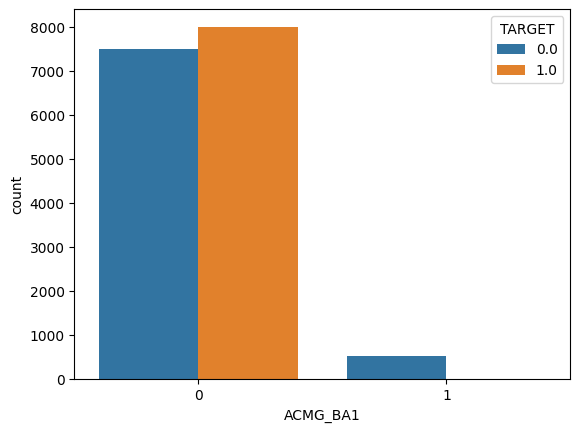

In [102]:
sns.countplot(data=X_train_eda_acmg, x='ACMG_BA1', hue='TARGET')
plt.show()


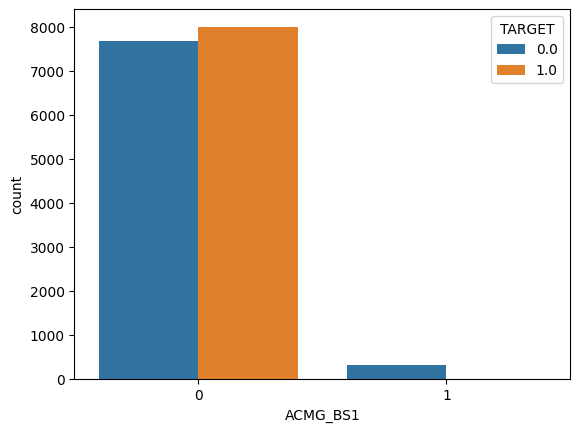

In [103]:
sns.countplot(data=X_train_eda_acmg, x='ACMG_BS1', hue='TARGET')
plt.show()

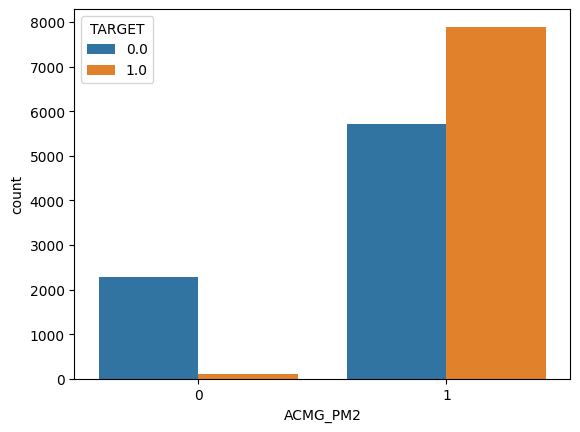

In [104]:
sns.countplot(data=X_train_eda_acmg, x='ACMG_PM2', hue='TARGET')
plt.show()

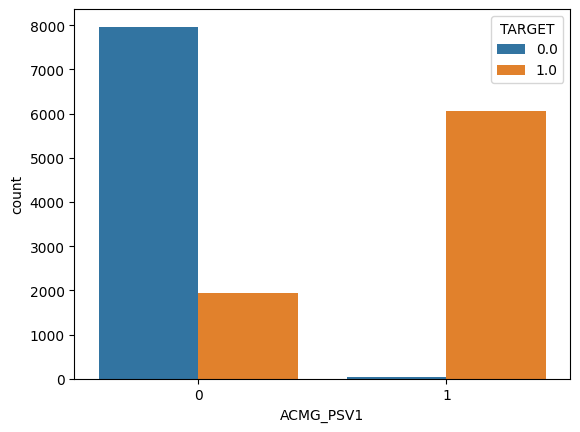

In [105]:
sns.countplot(data=X_train_eda_acmg, x='ACMG_PSV1', hue='TARGET')
plt.show()

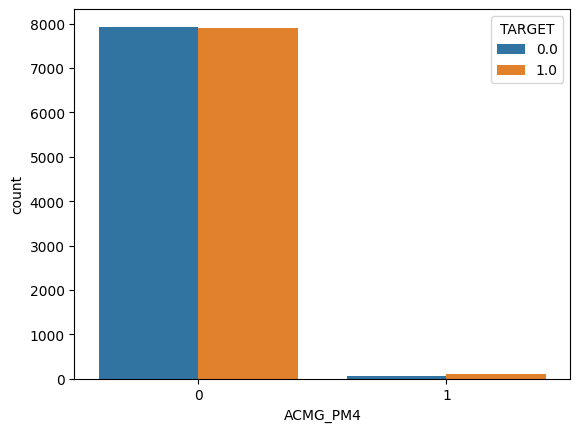

In [106]:
sns.countplot(data=X_train_eda_acmg, x='ACMG_PM4', hue='TARGET')
plt.show()

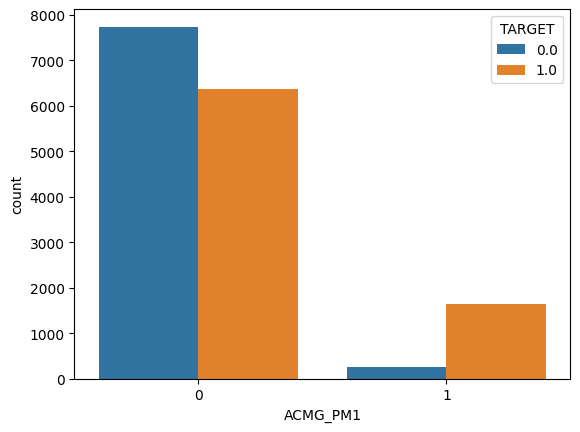

In [107]:
sns.countplot(data=X_train_eda_acmg, x='ACMG_PM1', hue='TARGET')
plt.show()

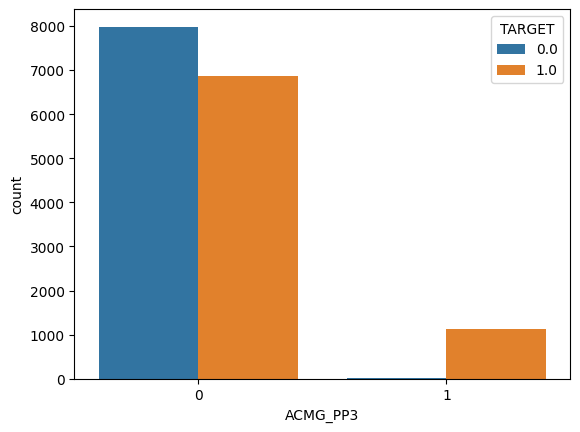

In [108]:
sns.countplot(data=X_train_eda_acmg, x='ACMG_PP3', hue='TARGET')
plt.show()

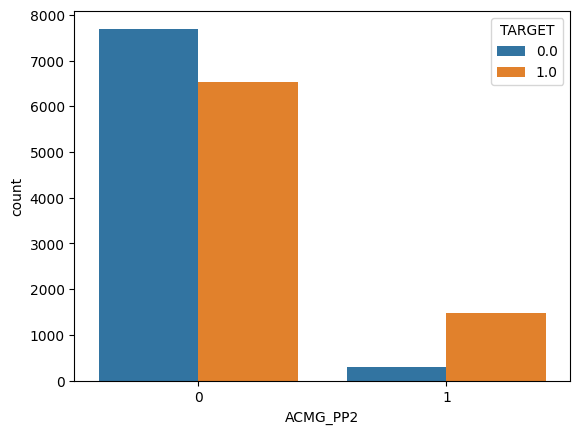

In [109]:
sns.countplot(data=X_train_eda_acmg, x='ACMG_PP2', hue='TARGET')
plt.show()

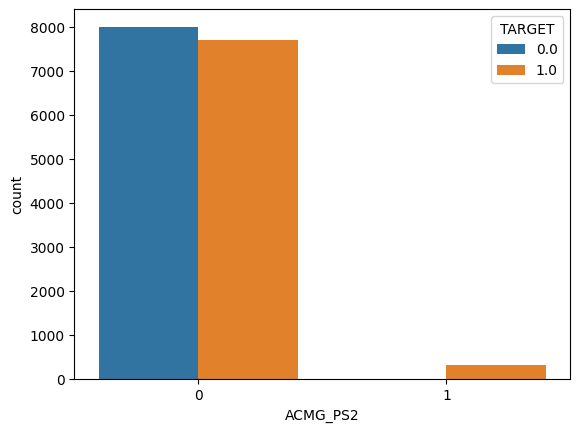

In [110]:
sns.countplot(data=X_train_eda_acmg, x='ACMG_PS2', hue='TARGET')
plt.show()

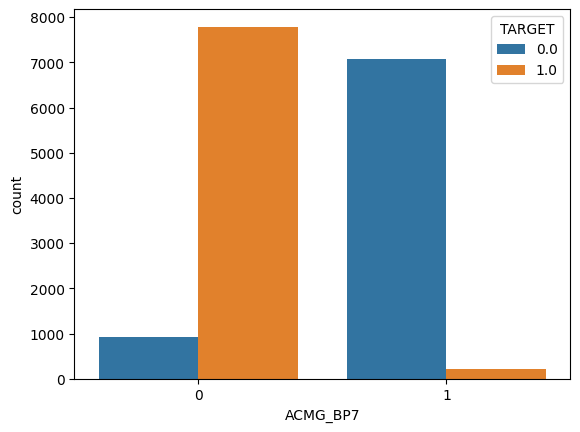

In [111]:
sns.countplot(data=X_train_eda_acmg, x='ACMG_BP7', hue='TARGET')
plt.show()

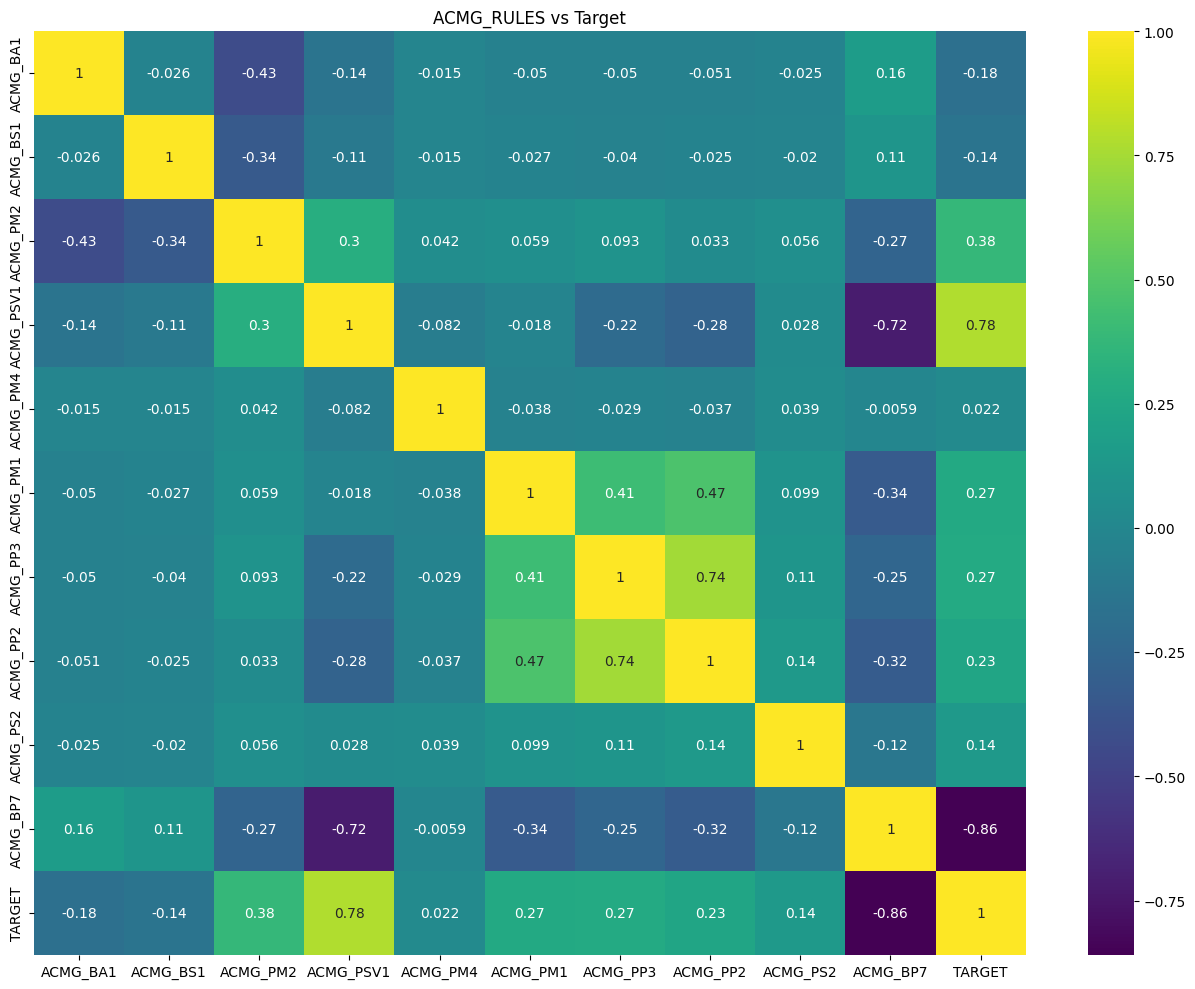

In [112]:
acmg_cols = [c for c in X_train_eda_acmg.columns if 'ACMG' in c]
cols_to_plot = acmg_cols + ['TARGET']

corr_matrix = X_train_eda_acmg[cols_to_plot].corr(method='spearman')
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='viridis')
plt.title('ACMG_RULES vs Target')
plt.show()

In [128]:
class AddAcmgRules(BaseEstimator, TransformerMixin):
    def __init__(self, af_threshold_benign=0.05, revel_threshold_pathogenic=0.75):
        self.af_threshold_benign = af_threshold_benign
        self.revel_threshold_pathogenic = revel_threshold_pathogenic
        

    def fit(self, X, y=None):
        return self
    
    def _apply_population_rules(self, df):
        df['ACMG_BA1'] = (df['MAX_AF'] > self.af_threshold_benign).astype(int)
        df['ACMG_BS1'] = ((df['MAX_AF'] > 0.01) & (df['MAX_AF'] <= self.af_threshold_benign)).astype(int)
        df['ACMG_PM2'] = (df['MAX_AF'] < 0.0001).astype(int)
        return df
    
    def _apply_structural_rules(self, df):
        df['ACMG_PSV1'] = (df['MC_IMPACT_SCORE'] == 2.0).astype(int)
        df['ACMG_PM4'] = ((df['DIFF_LEN'] != 0) & (df['is_frameshift'] == 0) & (df['MC_IMPACT_SCORE'] != 2.0)).astype(int)
        return df
    
    def _apply_computational_rules(self, df):
        col = 'dbnsfp.revel.score'
        df['ACMG_PP3'] = ((df[col] > self.revel_threshold_pathogenic) & (df[col] != -1)).astype(int)
        return df
    
    def _apply_domain_rules(self, df):
        df['ACMG_PM1'] = df['is_in_critical_domain']
        return df

    def _apply_evolution_rules(self, df):
        df['ACMG_PP2'] = ((df['dbnsfp.phylop.100way_vertebrate.score'] > 2.0) & (df['MC_IMPACT_SCORE'] == 1.0)).astype(int)
        return df 

    def _apply_origin_rules(self, df):
        df['ACMG_PS2'] = ((df['ORIGIN_GROUPED_32'] == 1) | (df['ORIGIN_GROUPED_33'] == 1)).astype(int)
        return df
    
    def _apply_synonumous_rules(self, df):
        is_synonymous = (df['MC_IMPACT_SCORE'] == 0)
        is_safe = True
        is_safe = ((df['dbnsfp.revel.score'] < 0.05) | (df['dbnsfp.revel.score'] == -1))
        df['ACMG_BP7'] = (is_safe & is_synonymous).astype(int)
        return df
    
    def transform(self, X):
        X_copy = X.copy()
        X_copy = self._apply_population_rules(X_copy)
        X_copy = self._apply_structural_rules(X_copy)
        X_copy = self._apply_domain_rules(X_copy)
        X_copy = self._apply_computational_rules(X_copy)
        X_copy = self._apply_evolution_rules(X_copy)
        X_copy = self._apply_origin_rules(X_copy)
        X_copy = self._apply_synonumous_rules(X_copy)
        return X_copy
    

In [129]:
class VariantsAtTributeExtractor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.chrom_map = {
            'X': 23,
            'Y': 24,
            'MT': 25, 
            'M': 25,
            'Mit': 25,
            'NT_187693.1': 99
        }
        self.af_cols = ['AF_EXAC', 'AF_TGP', 'AF_ESP', 'gnomad_exome.af.af']

    def fit(self, X, y=None):
        return self
    
    def _is_transition_checker(self, X) -> pd.DataFrame:
        cond_AG = (X['REF'] == 'A') & (X['ALT'] == 'G')
        cond_GA = (X['REF'] == 'G') & (X['ALT'] == 'A')
        cond_CT = (X['REF'] == 'C') & (X['ALT'] == 'T')
        cond_TC = (X['REF'] == 'T') & (X['ALT'] == 'C')
        X['is_transition'] = (cond_AG | cond_GA | cond_CT | cond_TC).astype(int)
        return X

    
    def transform(self, X) -> pd.DataFrame:
        X_copy = X.copy()
        for col in self.af_cols:
            X_copy[col] = pd.to_numeric(X_copy[col], errors='coerce')
        X_copy['MAX_AF'] = X_copy[self.af_cols].max(axis=1)
        X_copy['DIFF_LEN'] = X_copy['ALT'].astype(str).str.len() - X_copy['REF'].astype(str).str.len()
        X_copy['is_frameshift'] = (X_copy['DIFF_LEN'] % 3 != 0).astype(int)
        X_copy = self._is_transition_checker(X_copy)
        X_copy['CHROM'] = X_copy['CHROM'].astype(str).replace(self.chrom_map)
        X_copy['CHROM'] = pd.to_numeric(X_copy['CHROM'], errors='coerce').fillna(99).astype(int)
        X_copy['is_in_critical_domain'] = X_copy['dbnsfp.interpro.domain'].notna().astype(int)
        X_copy = X_copy.drop(columns=['dbnsfp.interpro.domain', 'ALT', 'REF', 'AF_EXAC', 'AF_TGP', 'AF_ESP', 'gnomad_exome.af.af', 'GENEINFO', 'CLNVC', 'CLNREVSTAT', 'CLNDN'], axis=1)
        return X_copy


In [130]:
class ImpactScoreEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, high_impact_keyword=None, medium_impact_keyword=None):
        if high_impact_keyword is None:
            self.high_impact_keyword = ['nonsense', 'frameshift', 'splice_acceptor', 'splice_donor', 'start_lost', 'stop_lost', 'initiator_codon']
        else:
            self.high_impact_keyword = high_impact_keyword
        if medium_impact_keyword is None:
            self.medium_impact_keyword = ['missense', 'inframe', 'protein_altering']
        else:
            self.medium_impact_keyword = medium_impact_keyword

    def fit(self, X, y=None):
        return self
    
    def _clean_mc_string(self, X):
        mc_series = X['MC'].astype(str)
        extracted = mc_series.str.extract(r'\|(\S*)', expand=False)
        extracted = extracted.fillna('')
        X['MC_CLEANED'] = extracted.str.replace(r',[^|]*', '', regex=True).str.lower()
        return X
    
    def _score_single_value(self, val):
        if any(keyword in val for keyword in self.high_impact_keyword):
            return 2
        if any(keyword in val for keyword in self.medium_impact_keyword):
            return 1
        return 0

    def transform(self, X):
        X_copy = X.copy()
        X_copy = self._clean_mc_string(X_copy)
        X_copy['MC_IMPACT_SCORE'] = X_copy['MC_CLEANED'].apply(self._score_single_value)
        X_copy = X_copy.drop(columns=['MC', 'MC_CLEANED'], axis=1, errors='ignore')
        return X_copy

In [131]:
class GeneRiskEstimator(BaseEstimator, TransformerMixin):
    def __init__(self, m=10):
        self.global_mean = None
        self.smooth_map = None
        self.m = m
        pass

    def fit(self, X, y):
        df= X.copy()
        df['TARGET'] = y.copy()
        gene_stats = df.groupby('GENE_SYMBOL')['TARGET'].agg(['count', 'mean'])
        self.global_mean = df['TARGET'].mean()
        self.smooth_map = (gene_stats['count'] * gene_stats['mean'] + self.m * self.global_mean) / (gene_stats['count'] + self.m)
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        X_copy['GENE_RISK'] = X_copy['GENE_SYMBOL'].map(self.smooth_map)
        X_copy['GENE_RISK'] = X_copy['GENE_RISK'].fillna(self.global_mean)
        X_copy = X_copy.drop(columns=['GENE_SYMBOL'], axis=1)
        return X_copy

In [136]:
class OriginRareLabelEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=50):
        self.threshold = threshold
        self.common_origin = None
        pass

    def fit(self, X, y=None):
        top_origins = X['ORIGIN'].value_counts()
        self.common_origin = set(top_origins[top_origins >= self.threshold].index)
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        X_copy['ORIGIN_GROUPED'] = X_copy['ORIGIN'].apply(lambda x: x if x in self.common_origin else 'other')
        X_copy['ORIGIN_GROUPED'] = X_copy['ORIGIN_GROUPED'].astype(str)
        X_copy = X_copy.drop(columns=['ORIGIN'], axis=1)
        return X_copy

In [137]:
class ZeroImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.fill_values = {
            'REF': '', 
            'ALT': '', 
            'MC': '', 
            'CHROM': '99',
            'dbnsfp.interpro.domain': '',
            'dbnsfp.revel.score': -1,
            'dbnsfp.phylop.100way_vertebrate.score': -1,
            'AF_EXAC': 0,
            'AF_TGP' : 0,
            'AF_ESP' : 0,
            'gnomad_exome.af.af' : 0,
            'GENE_SYMBOL': '',
            'GENEINFO': ''
        }
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        for col, val in self.fill_values.items():
            if col in X_copy.columns:
                X_copy[col] = X_copy[col].fillna(val)
        return X_copy

In [138]:
X_debug = X_train.copy()
y_debug = y_train.copy()
cleaner = ZeroImputer()
X_debug = cleaner.transform(X_train)
exc = VariantsAtTributeExtractor()
X_debug = exc.transform(X_debug)
impact_enc = ImpactScoreEncoder()
X_debug = impact_enc.transform(X_debug)
gene_enc = GeneRiskEstimator(m=10)
X_debug = gene_enc.fit_transform(X_debug, y_debug)
origin_enc = OriginRareLabelEncoder(threshold=50)
X_debug = origin_enc.fit_transform(X_debug, y_debug)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
origin_ohe_array = ohe.fit_transform(X_debug[['ORIGIN_GROUPED']])
feature_names = ohe.get_feature_names_out(['ORIGIN_GROUPED'])
origin_ohe_df = pd.DataFrame(
    origin_ohe_array, 
    columns=feature_names, 
    index=X_debug.index
)
X_debug = pd.concat([X_debug, origin_ohe_df], axis=1).drop(columns=['ORIGIN_GROUPED'])

In [139]:
X_debug.head()

,CHROM,POS,dbnsfp.phylop.100way_vertebrate.score,dbnsfp.revel.score,MAX_AF,DIFF_LEN,is_frameshift,is_transition,is_in_critical_domain,MC_IMPACT_SCORE,GENE_RISK,ORIGIN_GROUPED_0,ORIGIN_GROUPED_1,ORIGIN_GROUPED_16,ORIGIN_GROUPED_32,ORIGIN_GROUPED_33,ORIGIN_GROUPED_4,ORIGIN_GROUPED_5,ORIGIN_GROUPED_other
13500,13,32337642,-1.000,-1.000,0.000000,1,1,0,1,2,0.794872,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4606,2,71568098,-1.000,-1.000,0.000000,0,0,0,1,0,0.584906,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5079,17,50056448,-1.000,-1.000,0.000000,0,0,0,1,0,0.428571,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
11798,9,95111630,-0.463,-1.000,0.000008,0,0,0,1,2,0.523810,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
19966,5,177292150,7.999,0.706,0.000000,0,0,0,1,1,0.678571,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [140]:
X_debug.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 19 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  int64  
 1   POS                                    16000 non-null  object 
 2   dbnsfp.phylop.100way_vertebrate.score  16000 non-null  float64
 3   dbnsfp.revel.score                     16000 non-null  float64
 4   MAX_AF                                 16000 non-null  float64
 5   DIFF_LEN                               16000 non-null  int64  
 6   is_frameshift                          16000 non-null  int64  
 7   is_transition                          16000 non-null  int64  
 8   is_in_critical_domain                  16000 non-null  int64  
 9   MC_IMPACT_SCORE                        16000 non-null  int64  
 10  GENE_RISK                              16000 non-null  float64
 11  ORIG

In [141]:
acmg = AddAcmgRules()
X_debug_acmg = acmg.transform(X_debug)

In [142]:
X_debug_acmg.head()

,CHROM,POS,dbnsfp.phylop.100way_vertebrate.score,dbnsfp.revel.score,MAX_AF,DIFF_LEN,is_frameshift,is_transition,is_in_critical_domain,MC_IMPACT_SCORE,...,ACMG_BA1,ACMG_BS1,ACMG_PM2,ACMG_PSV1,ACMG_PM4,ACMG_PM1,ACMG_PP3,ACMG_PP2,ACMG_PS2,ACMG_BP7
13500,13,32337642,-1.000,-1.000,0.000000,1,1,0,1,2,...,0,0,1,1,0,1,0,0,0,0
4606,2,71568098,-1.000,-1.000,0.000000,0,0,0,1,0,...,0,0,1,0,0,1,0,0,0,1
5079,17,50056448,-1.000,-1.000,0.000000,0,0,0,1,0,...,0,0,1,0,0,1,0,0,0,1
11798,9,95111630,-0.463,-1.000,0.000008,0,0,0,1,2,...,0,0,1,1,0,1,0,0,0,0
19966,5,177292150,7.999,0.706,0.000000,0,0,0,1,1,...,0,0,1,0,0,1,0,1,0,0


In [143]:
X_debug_acmg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  int64  
 1   POS                                    16000 non-null  object 
 2   dbnsfp.phylop.100way_vertebrate.score  16000 non-null  float64
 3   dbnsfp.revel.score                     16000 non-null  float64
 4   MAX_AF                                 16000 non-null  float64
 5   DIFF_LEN                               16000 non-null  int64  
 6   is_frameshift                          16000 non-null  int64  
 7   is_transition                          16000 non-null  int64  
 8   is_in_critical_domain                  16000 non-null  int64  
 9   MC_IMPACT_SCORE                        16000 non-null  int64  
 10  GENE_RISK                              16000 non-null  float64
 11  ORIG

In [144]:
cols_to_ohe = ['ORIGIN_GROUPED', 'CHROM']
cols_to_scale = ['POS', 'DIFF_LEN']

preprocessor = Pipeline([
    ('zero_imputer', ZeroImputer()),
    ('variants_extractor', VariantsAtTributeExtractor()),
    ('impact_encoder', ImpactScoreEncoder()),
    ('gene_risk', GeneRiskEstimator(m=10)),
    ('origin_grouped', OriginRareLabelEncoder(threshold=50)),
    ('ohe_step', ColumnTransformer(
        [
            ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cols_to_ohe)
        ], 
        remainder='passthrough',
        verbose_feature_names_out=False
    )),
    ('acmg_rules', AddAcmgRules()),
    ('scaler_step', ColumnTransformer([
        ('scaler', StandardScaler(), cols_to_scale)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
    ))
])

In [145]:
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(random_state=42))
])

model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('zero_imputer', ...), ('variants_extractor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,high_impact_keyword,"['nonsense', 'frameshift', ...]"
,medium_impact_keyword,"['missense', 'inframe', ...]"
,m,10


In [146]:
print(f'Train score: {model_pipeline.score(X_train, y_train)}')
print(f'Test score: {model_pipeline.score(X_test, y_test)}')

Train score: 0.9924375
Test score: 0.97


In [147]:
y_test_pred = model_pipeline.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97      2000
         1.0       0.97      0.97      0.97      2000

    accuracy                           0.97      4000
   macro avg       0.97      0.97      0.97      4000
weighted avg       0.97      0.97      0.97      4000



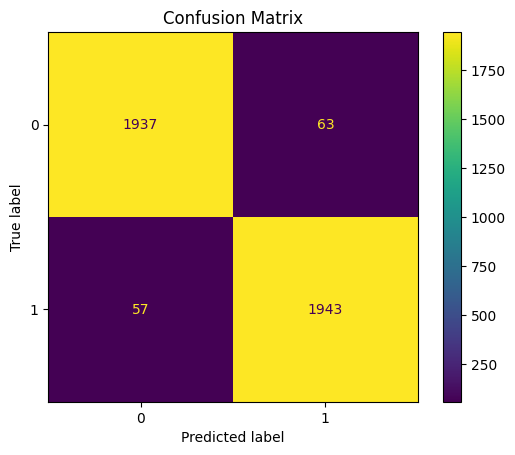

In [148]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='viridis')
plt.title('Confusion Matrix')
plt.show()


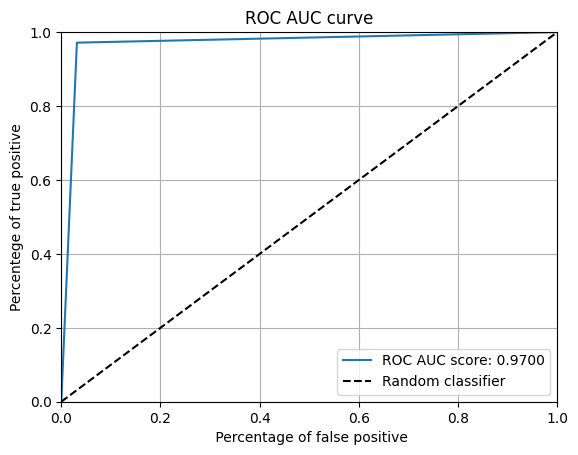

In [149]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_pred)

plt.plot(fpr, tpr, label=f'ROC AUC score: {test_auc:.4f}')
plt.plot([0,1], [0, 1], 'k--', label='Random classifier')
plt.xlabel(' Percentage of false positive')
plt.ylabel('Percentege of true positive')
plt.axis([0, 1, 0, 1])
plt.title('ROC AUC curve')
plt.legend()
plt.grid()
plt.show()

In [150]:
warnings.filterwarnings("ignore", category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

mlflow.set_tracking_uri('file:./mlruns')
experiment_name = 'ACMG_XGBoost_optuna'
mlflow.set_experiment(experiment_name)

mlflow_callback = MLflowCallback(
    tracking_uri=mlflow.get_tracking_uri(),
    metric_name='roc_auc',
    create_experiment=False
)

def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),  
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True), 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'objective': 'binary:logistic',
        'eval_metric': 'logloss', 
        'random_state': 42,
        'n_jobs': 1,
    }
    model = XGBClassifier(**params)
    model_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    scores = cross_val_score(model_pipeline, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
    return np.mean(scores)

study_name = 'xgb-acmg-tuning'
storage_name = f"sqlite:///{study_name}.db"

study = optuna.create_study(
    study_name=study_name,
    storage=storage_name,
    load_if_exists=True,
    direction='maximize'
)

study.optimize(objective, n_trials=50, n_jobs=1, callbacks=[mlflow_callback])

print(f"ROC AUC best score: {study.best_value:.4f}")

best_params = study.best_params
best_params['n_jobs'] = -1

with mlflow.start_run(run_name='Best_XGB_Optuna') as run:
    mlflow.log_params(best_params)
    mlflow.log_metric('final_roc_auc', study.best_value)
    final_model = XGBClassifier(**best_params)
    final_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('final_model', final_model)
    ])
    final_pipeline.fit(X_train, y_train)
    mlflow.sklearn.log_model(final_pipeline, artifact_path='model')
    run_id = run.info.run_id
    print('Model saved in MLflow!')
    print(f'Run ID: {run_id}')

C:\Users\szymo\AppData\Local\Temp\ipykernel_16156\876835998.py:8: ExperimentalWarning: MLflowCallback is experimental (supported from v1.4.0). The interface can change in the future.
  mlflow_callback = MLflowCallback(


ROC AUC best score: 0.9933


2026/01/06 22:29:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Model saved in MLflow!
Run ID: d4791266f3584b24a82dafd7e5f25f47


In [152]:
run_id = 'd4791266f3584b24a82dafd7e5f25f47'
print(f'Reading model from: {run_id}')
model_uri = f'runs:/{run_id}/model'
loaded_model = mlflow.sklearn.load_model(model_uri)

y_pred_proba = loaded_model.predict_proba(X_test)[:, 1]
val_auc = roc_auc_score(y_test, y_pred_proba)
print(f'AUC score on test data: {val_auc}')

Reading model from: d4791266f3584b24a82dafd7e5f25f47


AUC score on test data: 0.9933336250000001


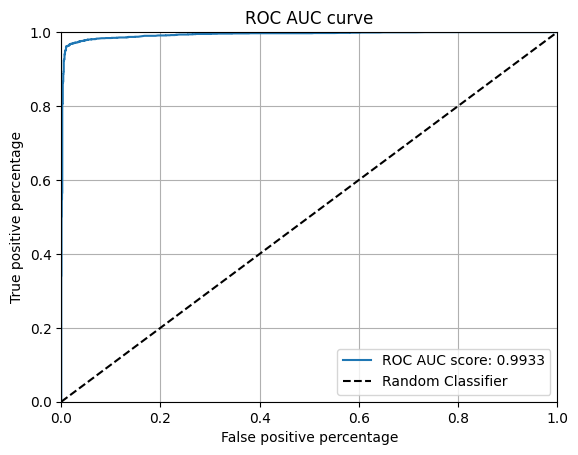

In [153]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.plot(fpr, tpr, label=f'ROC AUC score: {val_auc:.4f}')
plt.plot([0,1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False positive percentage')
plt.ylabel('True positive percentage')
plt.axis([0, 1, 0, 1])
plt.title('ROC AUC curve')
plt.legend()
plt.grid()
plt.show()

### 📊 ROC AUC Analysis
**Conclusion:** The model achieves an **AUC of 0.993**, indicating exceptional separability between pathogenic and benign classes.
* The curve's steep ascent shows a high True Positive Rate (Recall) with minimal False Positives.
* High performance is driven by strong predictors like `MC_IMPACT_SCORE` and the removal of noisy data (VUS), creating a distinct decision boundary.

In [154]:
y_test_pred = loaded_model.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

         0.0       0.97      0.98      0.98      2000
         1.0       0.98      0.97      0.97      2000

    accuracy                           0.97      4000
   macro avg       0.98      0.98      0.97      4000
weighted avg       0.98      0.97      0.97      4000



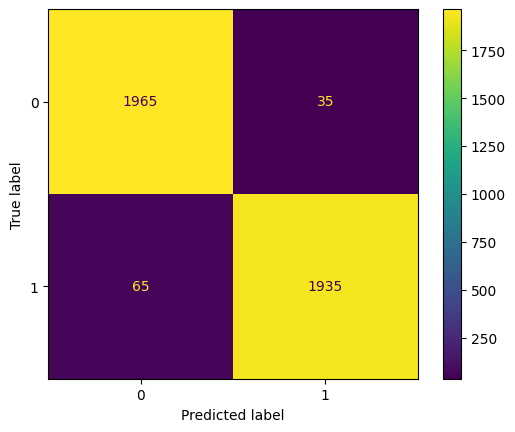

In [155]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='viridis')
plt.show()

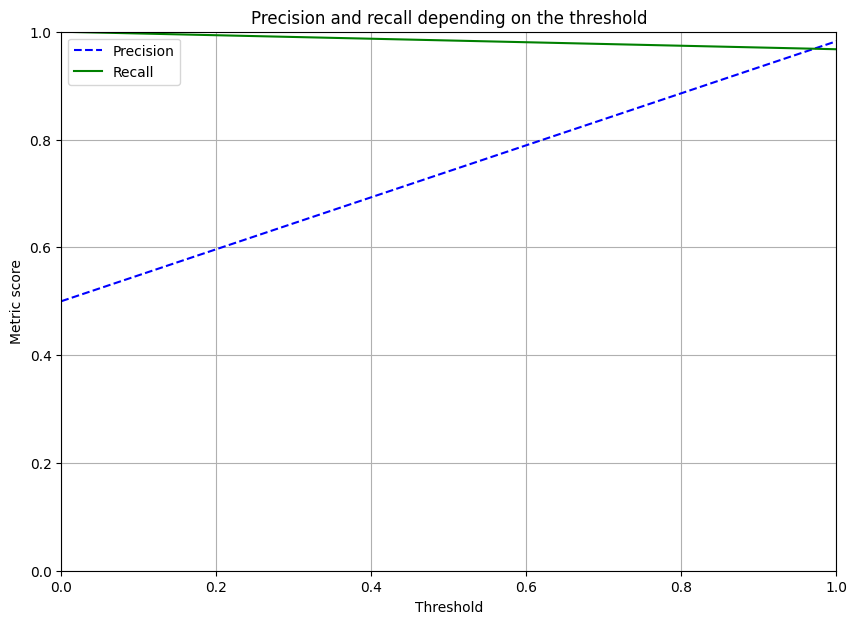

In [156]:
precision, recall, thresholds = precision_recall_curve(y_test, y_test_pred)

plt.figure(figsize=(10, 7))
plt.plot(thresholds, precision[:-1], "b--", label="Precision") 
plt.plot(thresholds, recall[:-1], "g-", label="Recall")      
plt.xlabel("Threshold")
plt.ylabel("Metric score")
plt.title("Precision and recall depending on the threshold")
plt.grid(True)
plt.legend()
plt.axis([0, 1, 0, 1])
plt.show()

### 🎯 Precision-Recall vs. Threshold
**Conclusion:** The stability of the Recall curve (green) indicates the model is highly robust.
* Even at strict probability thresholds (e.g., >0.8), the model retains high sensitivity, which is critical in clinical diagnostics to avoid missing pathogenic variants (False Negatives).
* The linear behavior reflects the high polarization of the model's probability outputs (see Histogram below).

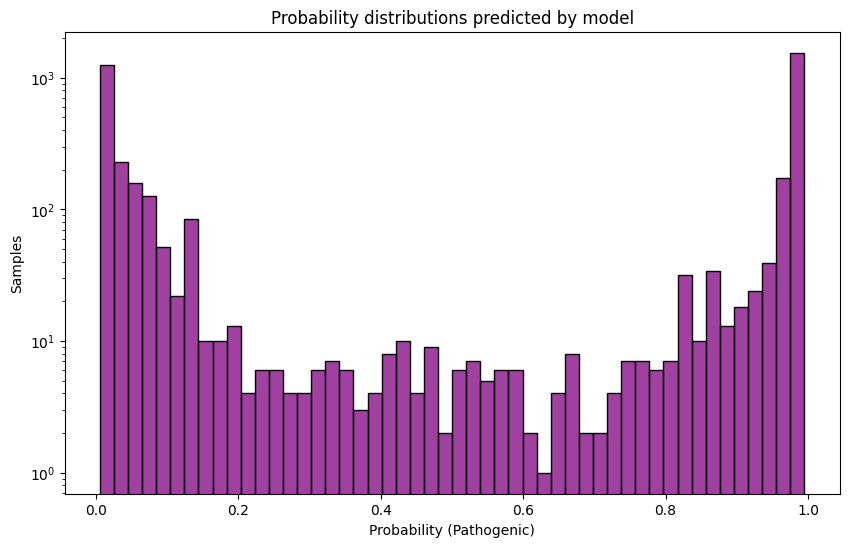

In [157]:
plt.figure(figsize=(10, 6))
sns.histplot(y_pred_proba, bins=50, kde=False, color='purple')
plt.title("Probability distributions predicted by model")
plt.xlabel("Probability (Pathogenic)")
plt.ylabel("Samples")
plt.yscale('log') 
plt.show()

### 📉 Probability Distribution (Model Confidence)
**Conclusion:** The log-scale histogram reveals a highly confident model.
* **Bimodal Distribution:** Over 98% of predictions are clustered near 0.0 (Benign) or 1.0 (Pathogenic).
* **Edge Cases:** Only a negligible fraction of variants fall into the uncertainty zone (0.4–0.6). These likely represent "hard examples" with conflicting biological evidence (e.g., rare variants with benign computational scores).

In [158]:
print(loaded_model.named_steps.keys())

dict_keys(['preprocessor', 'final_model'])


In [159]:
model_xgb = loaded_model.named_steps['final_model']
preprocessor = loaded_model.named_steps['preprocessor']
X_test_transformed = preprocessor.transform(X_test)

explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer(X_test_transformed)

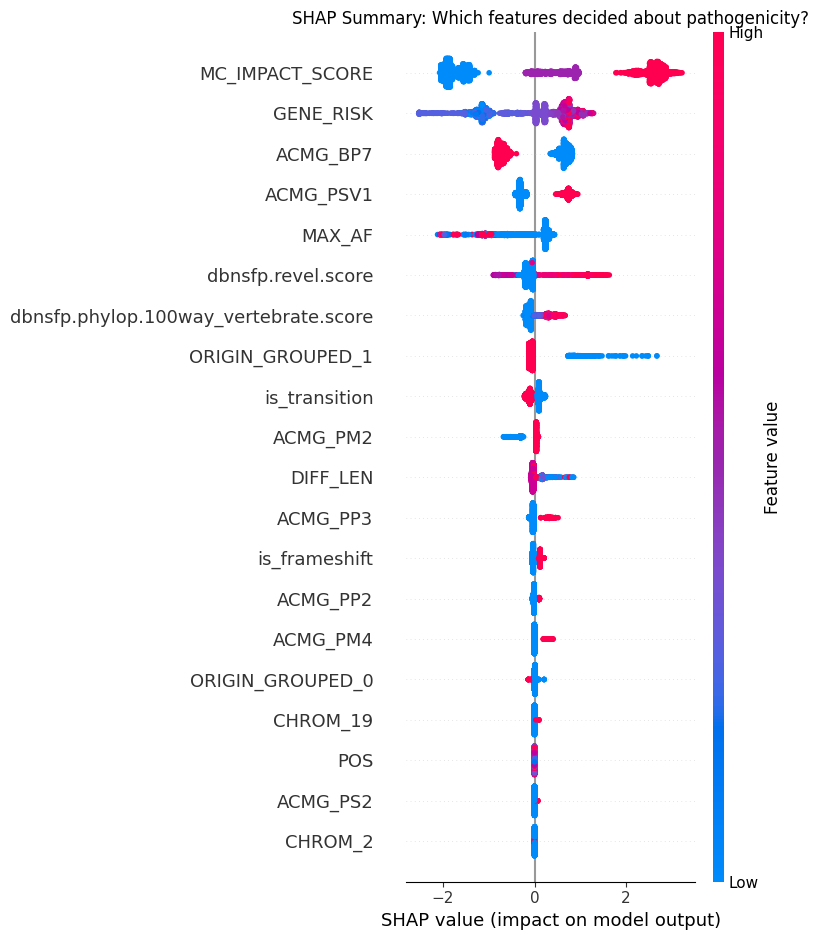

In [160]:
plt.title("SHAP Summary: Which features decided about pathogenicity?")
shap.summary_plot(shap_values, X_test_transformed, show=False)
plt.tight_layout()
plt.show()

### 🧠 SHAP Explainability Analysis
**Conclusion:** The model validates biological consensus, proving it is not overfitting to noise.
1.  **`MC_IMPACT_SCORE` (Top Feature):** High values (red dots) push predictions toward "Pathogenic" (right), aligning with the fact that protein-truncating variants are often deleterious.
2.  **`MAX_AF` (Allele Frequency):** High values (red dots) strongly push predictions toward "Benign" (left), consistent with the biological rule that common variants are rarely pathogenic.
3.  **ACMG Rules:** Specific encoded rules (e.g., `ACMG_PVS1`) serve as strong directional predictors.

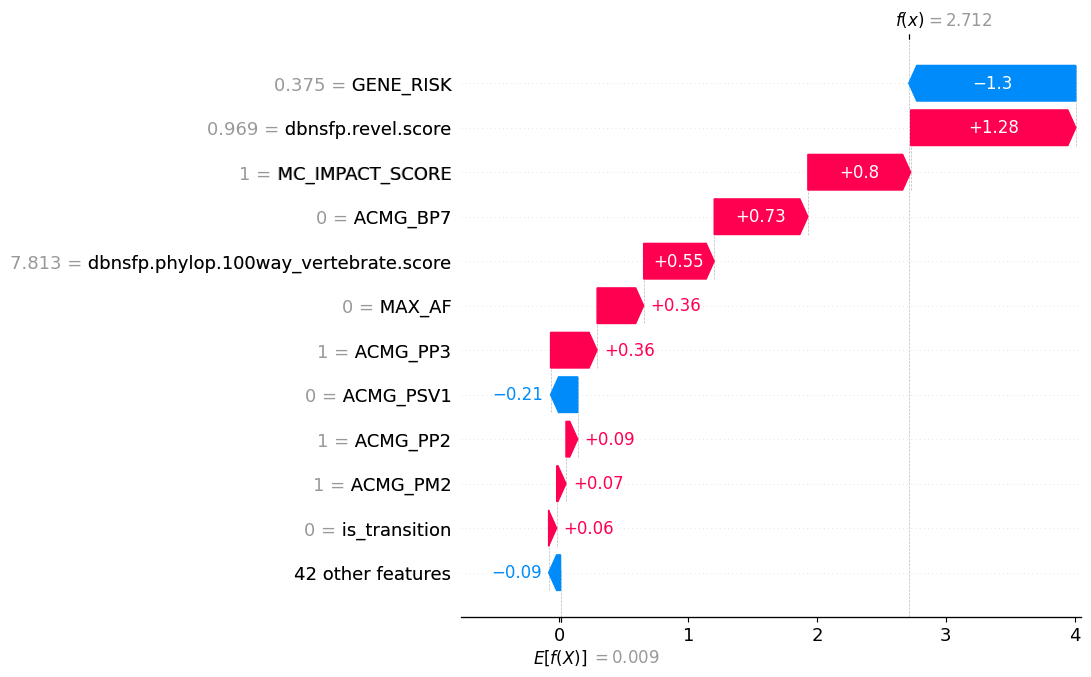

In [161]:
idx = 0
plt.figure(figsize=(8, 6))
shap.plots.waterfall(shap_values[idx], max_display=12, show=True)

### 🔍 Local Interpretation: Why is this specific variant Pathogenic?
**Case Study (Sample Index 0):**
The waterfall plot illustrates the decision path for a single high-confidence pathogenic prediction ($f(x) = 4.38$, Probability > 98%).

* **Baseline:** The prediction starts at the average dataset value (near 0).
* **Key Drivers (Red Bars):**
    1.  **`dbnsfp.revel.score` (1.28):** A high in-silico pathogenicity prediction is the strongest contributor (+1.28).
    2.  **`MC_IMPACT_SCORE` (0.8):** The variant has a severe molecular consequence (e.g., Stop Gain/Frameshift), adding +0.8 to the risk score.
    3.  **`MAX_AF` (0.0):** The variant is absent in population databases (rare), which further supports pathogenicity (+0.36).
* **Conclusion:** The convergence of computational evidence (REVEL), biological impact, and rarity drives the model to a decisive "Pathogenic" classification.